In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from leadtime import analyze_run, get_conversion_month, _parse_list, run_grid, aggregate_grid, mean_ci

def _read_prob_pair(prog_path, ctrl_path):
    prog_df = pd.read_csv(prog_path)
    ctrl_df = pd.read_csv(ctrl_path)
    for df in (prog_df, ctrl_df):
        df['months_since_baseline'] = df['months_since_baseline'].apply(_parse_list)
        df['Progression'] = df['Progression'].apply(_parse_list)
    return {'prog': prog_df, 'ctrl': ctrl_df}

def load_cached_runs(cohort_dir):
    """Return {run_key: {'prog': df, 'ctrl': df}} for every cached run under cohort_dir.
    Handles BOTH layouts:
      - nested (MICE-imputed): {variant}/draw{d}/lead_time_probabilities.csv  ← preferred
      - flat   (non-imputed):  {seed}/lead_time_probabilities.csv
    run_key is 'variant_draw' for the first, 'seed' for the second.

    Nested draw folders are preferred whenever present, so legacy flat CSVs left
    beside them are ignored and a cache rebuild is always picked up."""
    runs = {}
    for entry in sorted(os.listdir(cohort_dir)):
        entry_dir = os.path.join(cohort_dir, entry)
        if not os.path.isdir(entry_dir):
            continue
        subs = sorted(d for d in os.listdir(entry_dir)
                      if os.path.isdir(os.path.join(entry_dir, d)))
        if subs:
            for sub in subs:
                sub_dir = os.path.join(entry_dir, sub)
                prog2 = os.path.join(sub_dir, 'lead_time_probabilities.csv')
                ctrl2 = os.path.join(sub_dir, 'control_probabilities.csv')
                if os.path.exists(prog2) and os.path.exists(ctrl2):
                    runs[f"{entry}_{sub}"] = _read_prob_pair(prog2, ctrl2)   # nested draw
        else:
            prog = os.path.join(entry_dir, 'lead_time_probabilities.csv')
            ctrl = os.path.join(entry_dir, 'control_probabilities.csv')
            if os.path.exists(prog) and os.path.exists(ctrl):
                runs[entry] = _read_prob_pair(prog, ctrl)                   # flat run
    return runs


## CN_MCI results

1. Analyze the false positive / true positive rates of predictions, how many conversions were predicted early, how many predictions were false alarms. This is a clinical diagnostic trial on a small subset. 
2. Produce a chart and some visualizations. 

## Averaged Detection-Outcome Bar Charts 

Creates the "Early / At conversion / Missed" bar chart using the true-conversion-month logic (`get_conversion_month`, threshold=0.25, mask_length=3) — and the resulting percentages are averaged across all cached runs per cohort/imputation (10 seeds for non-imputed, 10 variants × 10 bootstrap draws for MICE-imputed), with error bars showing the spread across runs.

non‑imputed CN_MCI:

    detected_early: 28.319327731092432 ± 0.6918257162592977 (27.824425427226014, 28.81423003495885

    detected_at_conversion: 61.26050420168067 ± 1.1515296801733585 (60.43674949251811, 62.084258910843225

    detected_late: 3.19327731092437 ± 0.5314752370030891 (2.8130828297724206, 3.5734717920763193

    missed: 7.226890756302519 ± 0.708633649337452 (6.719964781433253, 7.733816731171785

MICE‑imputed CN_MCI:

    detected_early: 29.126050420168067 ± 4.213073426325845 (28.290085249121415, 29.96201559121472

    detected_at_conversion: 60.99159663865546 ± 4.676780764916603 (60.063621871431735, 61.91957140587918

    detected_late: 3.4453781512605044 ± 1.8251303271901527 (3.0832326978681754, 3.8075236046528333

    missed: 6.436974789915966 ± 2.3594197010357068 (5.9688147332641055, 6.905134846567826

non‑imputed MCI_AD:

    detected_early: 23.544303797468352 ± 1.8099249442638996 (22.24956148926861, 24.839046105668093

    detected_at_conversion: 55.316455696202524

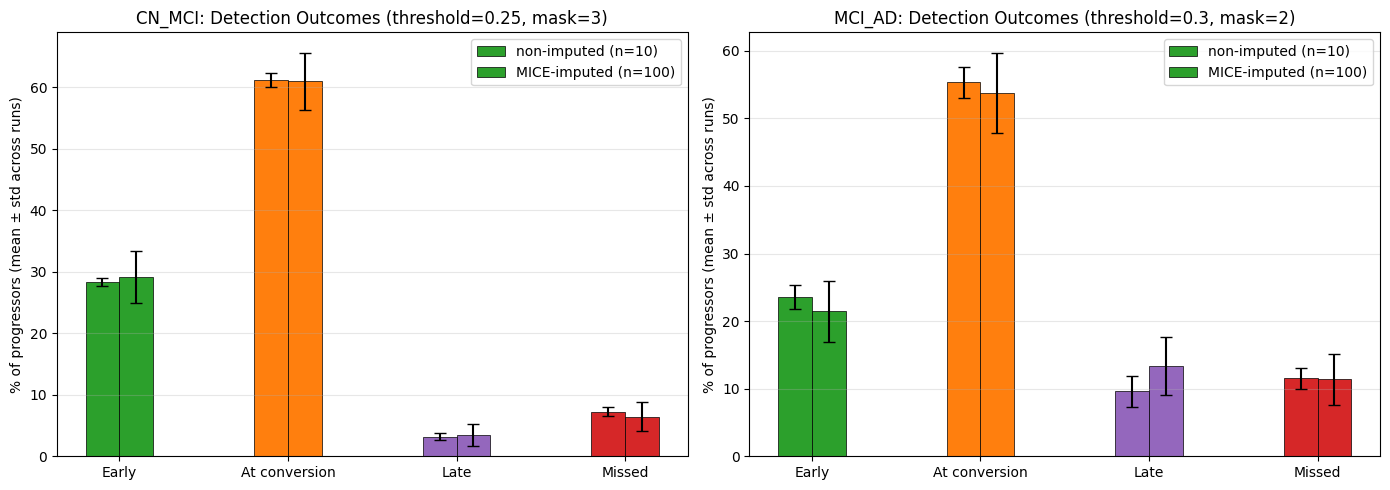

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────
THRESHOLD = [0.25, 0.3]
MASK_LENGTH = [3, 2]
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]

STATUS_ORDER = ["detected_early", "detected_at_conversion", "detected_late", "missed"]
STATUS_LABELS = ["Early", "At conversion", "Late", "Missed"]
COLORS = {"detected_early": "#2ca02c", "detected_at_conversion": "#ff7f0e",
          "detected_late": "#9467bd", "missed": "#d62728"}
status_colors = [COLORS[s] for s in STATUS_ORDER]

# ── Score every cached run ──
per_model_pct = {}

for imp in IMPUTATIONS:
    for index, cohort in enumerate(COHORTS):
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        rows = []
        for run_key, dfs in load_cached_runs(cohort_dir).items():
            res = analyze_run(dfs['prog'], dfs['ctrl'], THRESHOLD[index], MASK_LENGTH[index])
            n_prog = res['n_prog']
            if n_prog == 0:
                continue
            rows.append({
                'model_key': run_key,            # e.g. CN_MCI_seed104  or  pooled_CN_variant0_draw3
                'early_pct':   res['n_early']   / n_prog * 100,
                'at_conv_pct': res['n_at_conv'] / n_prog * 100,
                'late_pct':    res['n_late']    / n_prog * 100,
                'missed_pct':  res['n_missed']  / n_prog * 100,
            })

        per_model_pct[(imp, cohort)] = pd.DataFrame(rows)

# ── Plot (unchanged) ──────────────────────────────────────────────────────
bar_width = 0.2
x = np.arange(len(STATUS_LABELS))

fig, axes = plt.subplots(1, len(COHORTS), figsize=(7 * len(COHORTS), 5))
if len(COHORTS) == 1:
    axes = [axes]

for index, (ax, cohort) in enumerate(zip(axes, COHORTS)):
    for i, imp in enumerate(IMPUTATIONS):
        df = per_model_pct.get((imp, cohort))
        if df is None or df.empty:
            continue
        
        means = [df['early_pct'].mean(), df['at_conv_pct'].mean(),
                 df['late_pct'].mean(), df['missed_pct'].mean()]
        stds  = [df['early_pct'].std(), df['at_conv_pct'].std(),
                 df['late_pct'].std(), df['missed_pct'].std()]

        STATUS_CAT = ['early_pct','at_conv_pct','late_pct','missed_pct']

        print(f"{imp} {cohort}:\n")
        for ind, status in enumerate(STATUS_ORDER):
            mean, ci_l, ci_h, std = mean_ci(df[STATUS_CAT[ind]])
            print(f"    {status}: {mean} ± {std} ({ci_l}, {ci_h})\n")


        offset = (i - (len(IMPUTATIONS) - 1) / 2) * bar_width
        ax.bar(x + offset, means, bar_width, yerr=stds, capsize=4,
               label=f"{imp} (n={len(df)})",
               color=status_colors, edgecolor='black', linewidth=0.5)

    ax.set_xticks(x)
    ax.set_xticklabels(STATUS_LABELS)
    ax.set_ylabel("% of progressors (mean ± std across runs)")
    ax.set_title(f"{cohort}: Detection Outcomes (threshold={THRESHOLD[index]}, mask={MASK_LENGTH[index]})")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("leadtime_detection_outcomes_averaged.png", dpi=300, bbox_inches='tight')
plt.show()

# Supplemental Doc, Start here

## Threshold × Mask-Length Grid (recomputed with corrected conversion-month logic)

Rebuilds the same sensitivity / specificity / mean-lead-time / false-alarm-rate vs. threshold (by mask length) charts as the earlier grid-search cell, but reads directly from the cached per-model probability CSVs and rescoring them with `analyze_run` (which uses the corrected `get_conversion_month` true-conversion logic) instead of re-fitting/re-running the models. Results are averaged across all cached runs per cohort/imputation (10 seeds for non-imputed, 100 bootstrap draws for MICE-imputed), matching the averaging approach used for the detection-outcome bar charts above.

Scoring non‑imputed – CN_MCI ( 10 models )...
Scoring non‑imputed – MCI_AD ( 10 models )...
Scoring MICE‑imputed – CN_MCI ( 100 models )...
Scoring MICE‑imputed – MCI_AD ( 100 models )...


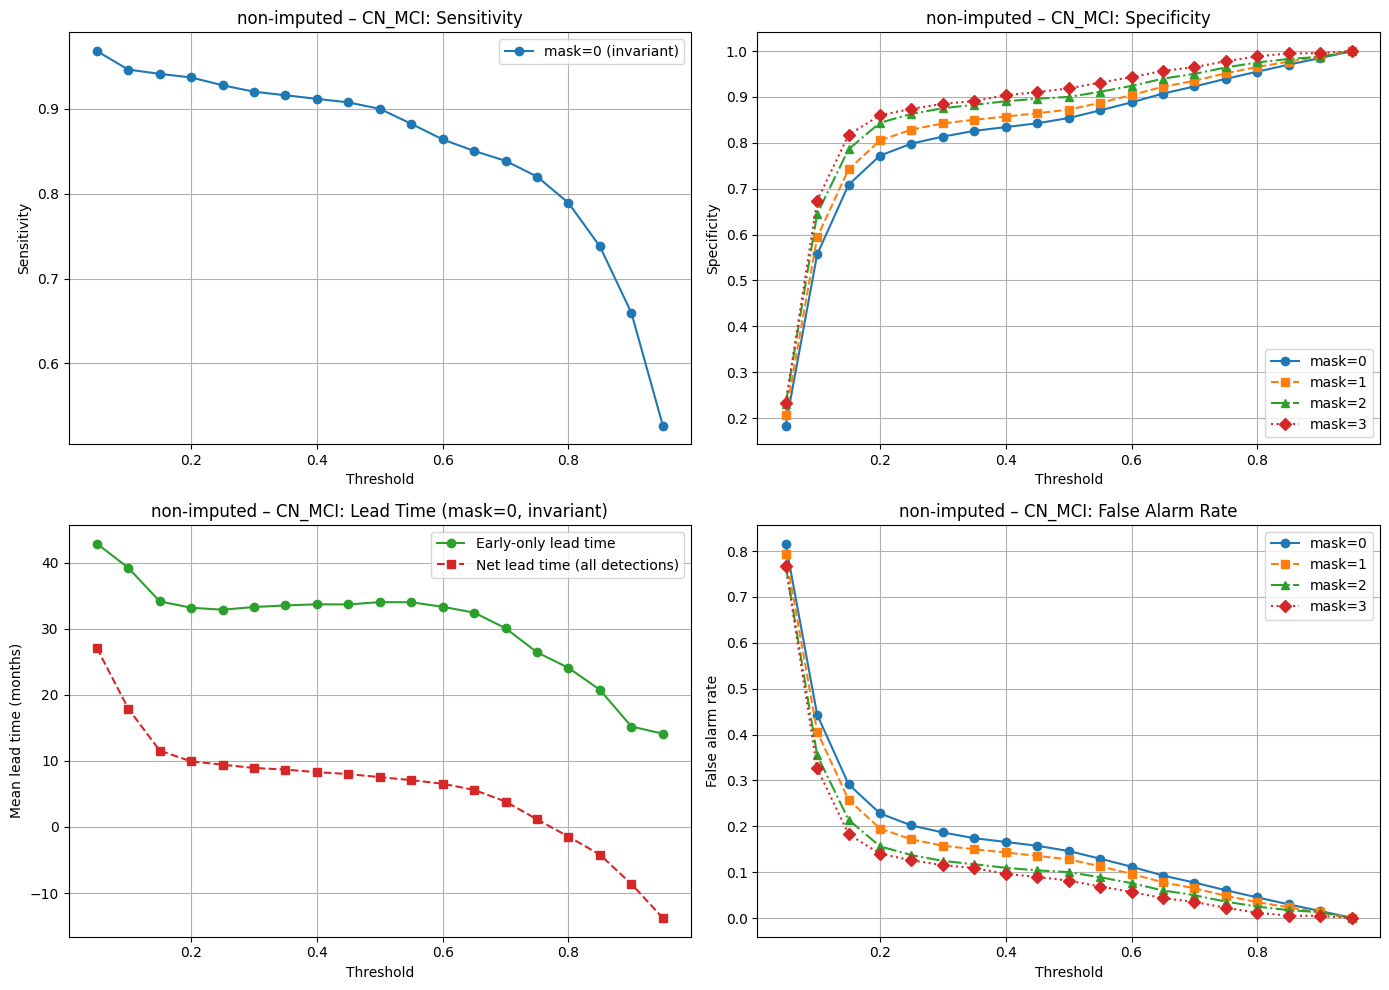

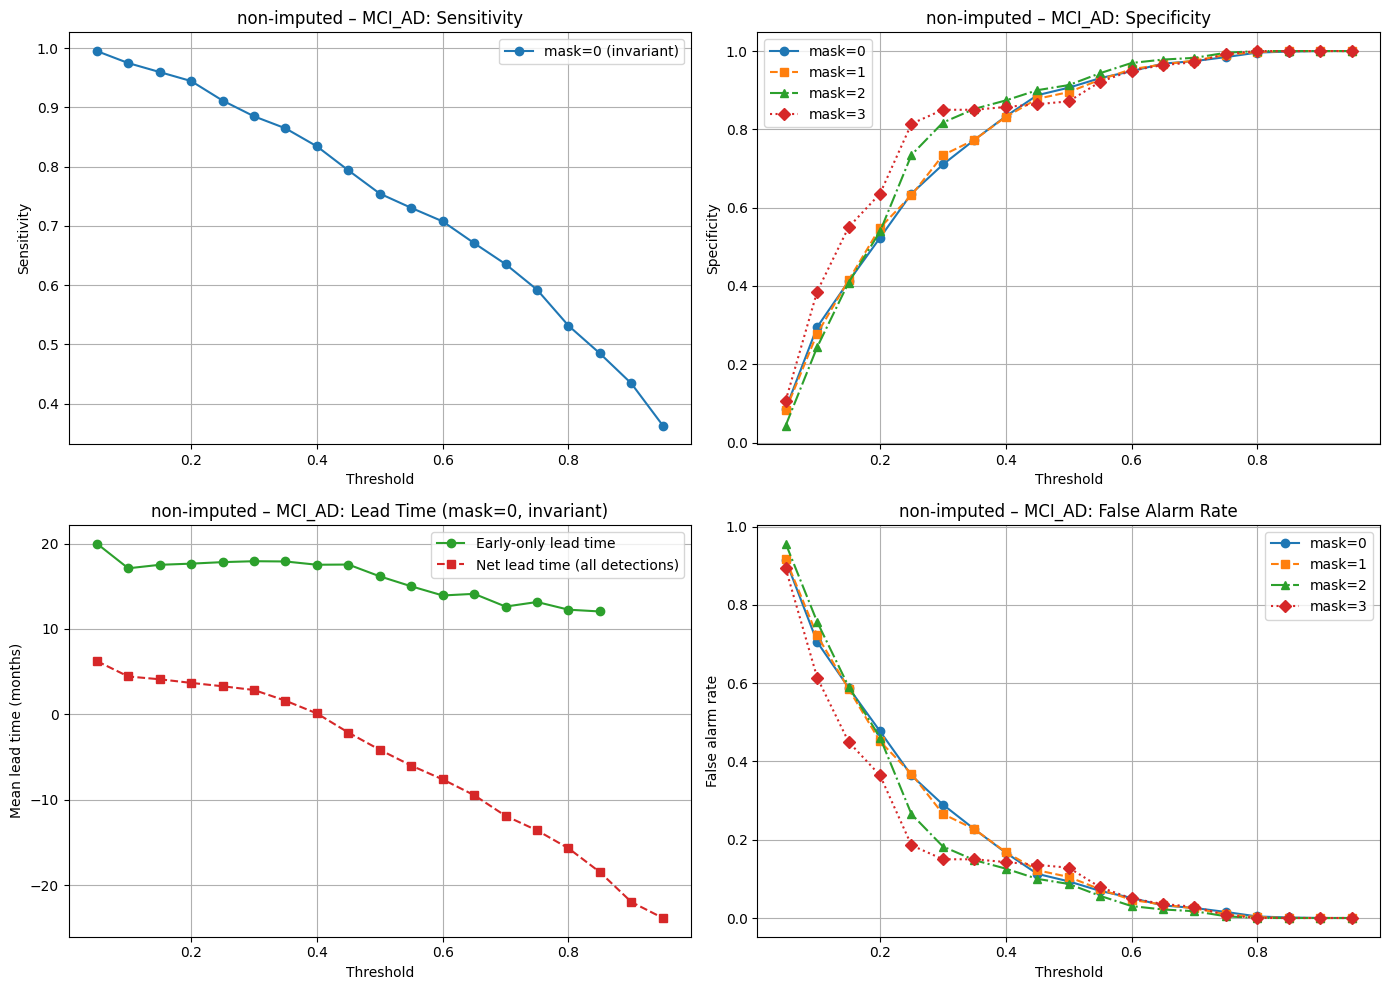

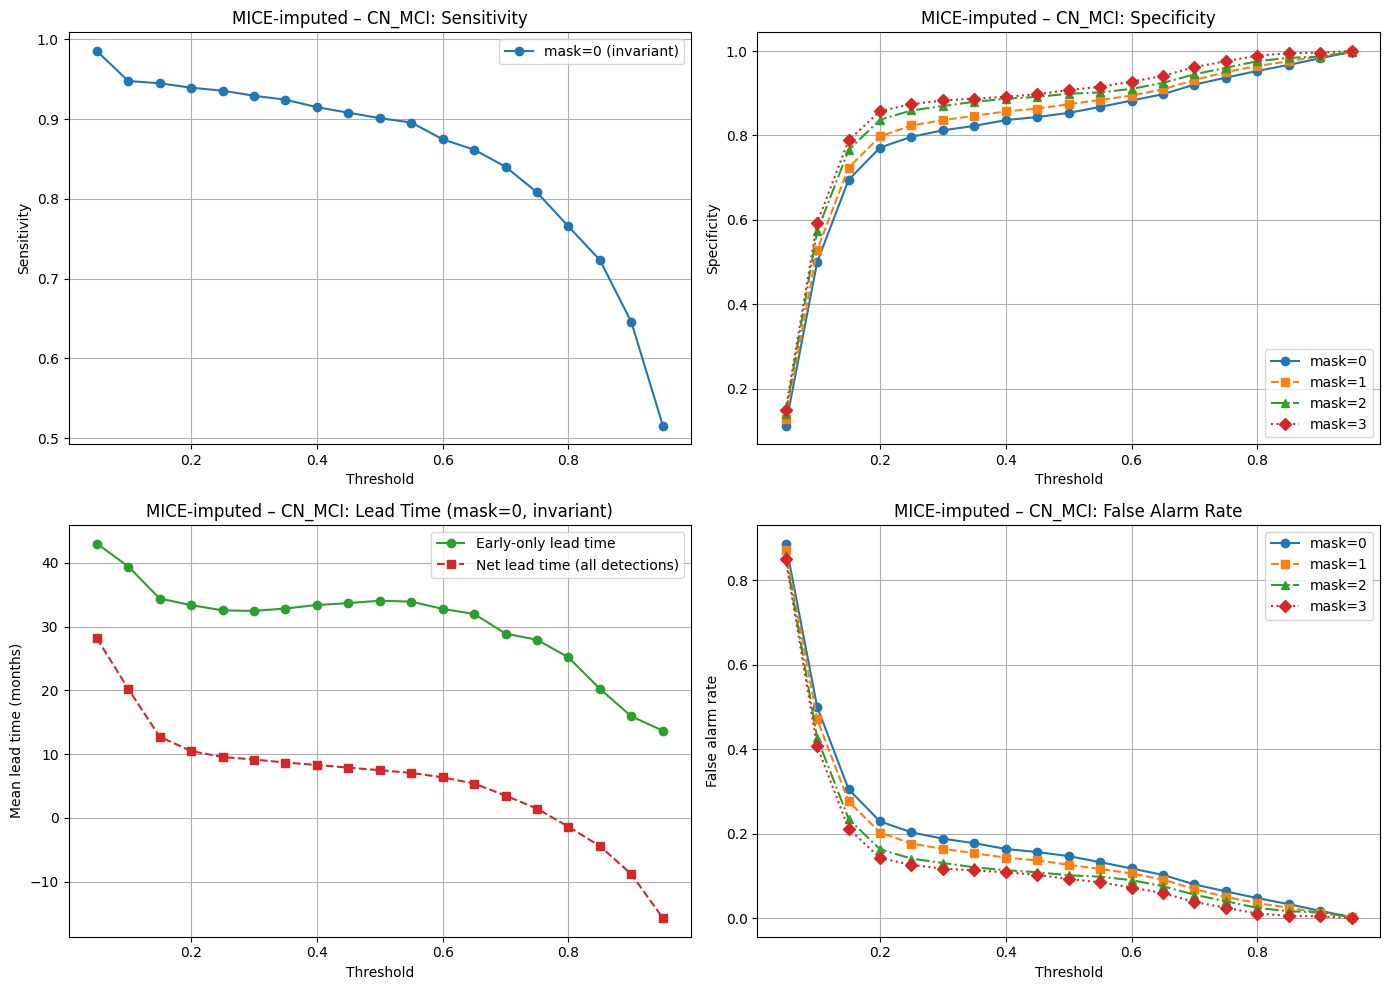

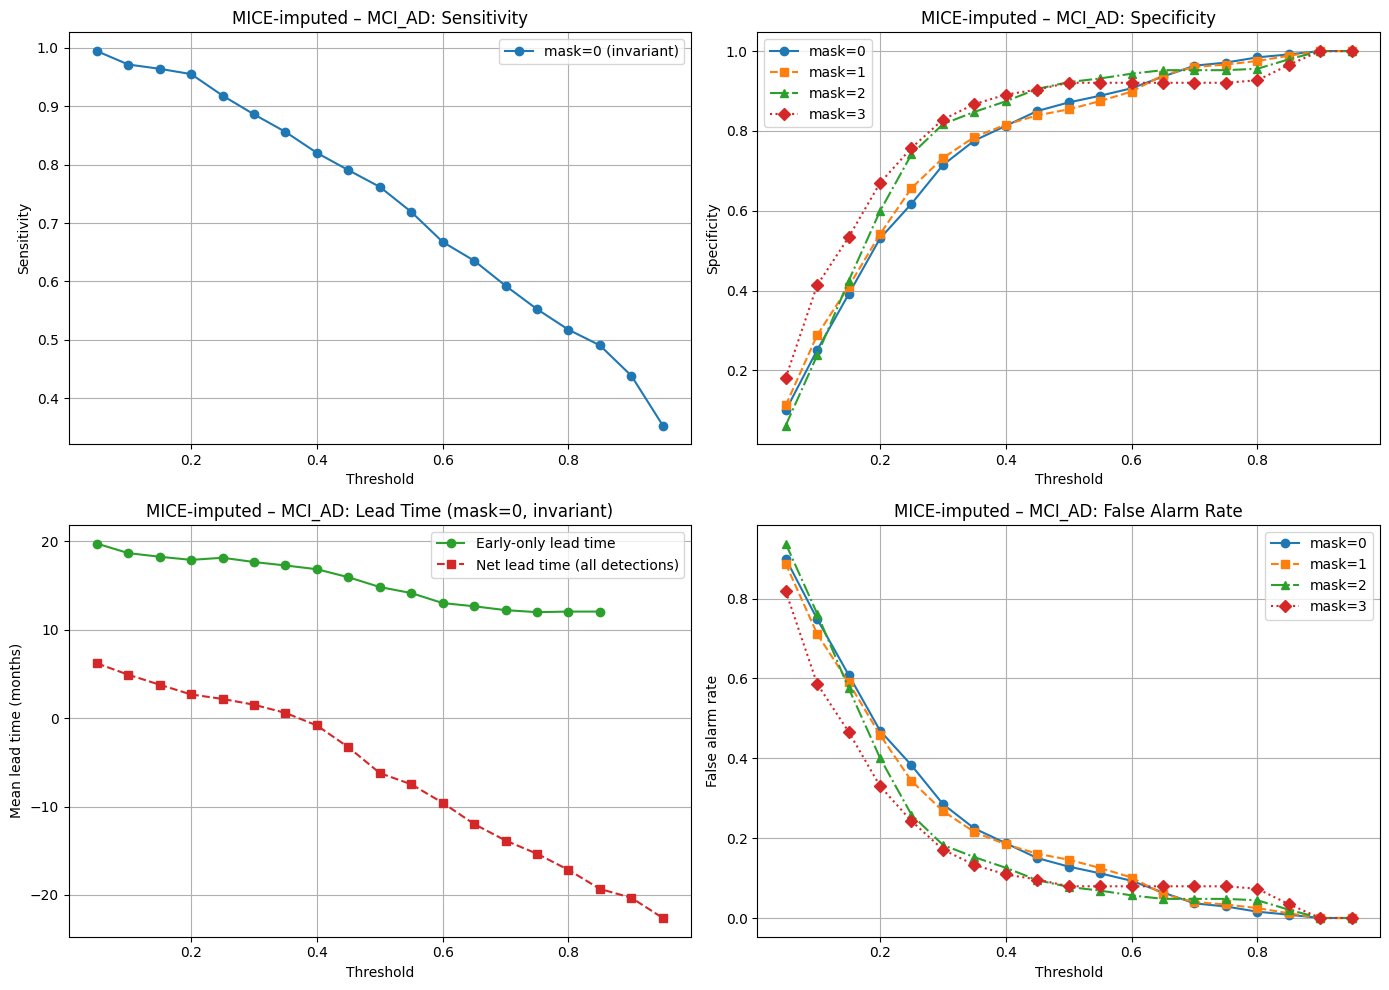

In [13]:
# ── Reload leadtime module to ensure updated functions are used ──
import importlib
import leadtime
importlib.reload(leadtime)
from leadtime import run_grid, aggregate_grid

# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
mask_lengths = [0, 1, 2, 3]

# ── Rebuild the full threshold × mask_length grid from cached probability CSVs ────
# load_cached_runs is nested-first: MICE-imputed uses the 10×10 bootstrap draws,
# non-imputed uses the flat per-seed CSVs.
all_results = {}  # {imputation: {cohort: agg_df}}

for imp in IMPUTATIONS:
    all_results[imp] = {}
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        prob_dict = load_cached_runs(cohort_dir)

        print(f"Scoring {imp} – {cohort} ( {len(prob_dict)} models )...")
        df_grid = run_grid(prob_dict, thresholds, mask_lengths)
        agg_df = aggregate_grid(df_grid)          # now includes n_late, n_at_conv, mean_net_lead_time, etc.
        all_results[imp][cohort] = agg_df
        agg_df.to_csv(f"leadtime_agg_{imp}_{cohort}.csv", index=False)


# ── Plotting: Sensitivity & lead time only for mask=0 (invariant); Specificity & FAR with all masks ──
LINESTYLES = {0: '-', 1: '--', 2: '-.', 3: ':'}
MARKERS = {0: 'o', 1: 's', 2: '^', 3: 'D'}

for imp, cohorts in all_results.items():
    for cohort, agg_df in cohorts.items():
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))

        # 1. Sensitivity vs threshold – only mask=0 (invariant)
        ax = axes[0, 0]
        sub = agg_df[agg_df['mask_length'] == 0]
        ax.plot(sub['threshold'], sub['sensitivity_mean'],
                linestyle='-', marker='o', color='#1f77b4', label='mask=0 (invariant)')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Sensitivity')
        ax.set_title(f'{imp} – {cohort}: Sensitivity')
        ax.legend()
        ax.grid(True)

        # 2. Specificity vs threshold – all masks
        ax = axes[0, 1]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['specificity_mean'],
                    linestyle=LINESTYLES[mask], marker=MARKERS[mask], label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Specificity')
        ax.set_title(f'{imp} – {cohort}: Specificity')
        ax.legend()
        ax.grid(True)

        # 3. Lead time vs threshold – only mask=0, showing both early-only and net
        ax = axes[1, 0]
        sub = agg_df[agg_df['mask_length'] == 0]
        # Early-only lead time (positive)
        ax.plot(sub['threshold'], sub['mean_lead_time_mean'],
                linestyle='-', marker='o', color='#2ca02c', label='Early-only lead time')
        # Net lead time (including late detections, may be negative)
        ax.plot(sub['threshold'], sub['mean_net_lead_time_mean'],
                linestyle='--', marker='s', color='#d62728', label='Net lead time (all detections)')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Mean lead time (months)')
        ax.set_title(f'{imp} – {cohort}: Lead Time (mask=0, invariant)')
        ax.legend()
        ax.grid(True)

        # 4. False alarm rate vs threshold – all masks
        ax = axes[1, 1]
        for mask in mask_lengths:
            sub = agg_df[agg_df['mask_length'] == mask]
            ax.plot(sub['threshold'], sub['false_alarm_rate_mean'],
                    linestyle=LINESTYLES[mask], marker=MARKERS[mask], label=f'mask={mask}')
        ax.set_xlabel('Threshold')
        ax.set_ylabel('False alarm rate')
        ax.set_title(f'{imp} – {cohort}: False Alarm Rate')
        ax.legend()
        ax.grid(True)

        plt.tight_layout()
        plt.savefig(f"leadtime_plots_{imp}_{cohort}.png", dpi=300, bbox_inches='tight')
        plt.show()


===== non‑imputed – CN_MCI: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.1 | 0.968 (0.958-0.978) | 0.184 (0.111-0.256) | 0.213 (0.198-0.229) | 0.957 (0.941-0.973) | 0.328 (0.271-0.386) | 0.349 (0.330-0.369) | 0.816 (0.744-0.889) | 42.884 (42.278-43.489) | 27.082 (25.968-28.197)
0.1 | 0.946 (0.943-0.949) | 0.557 (0.517-0.596) | 0.328 (0.307-0.349) | 0.979 (0.977-0.980) | 0.629 (0.597-0.660) | 0.486 (0.464-0.509) | 0.443 (0.404-0.483) | 39.214 (37.516-40.911) | 17.904 (15.926-19.882)
0.1 | 0.941 (0.938-0.944) | 0.709 (0.690-0.728) | 0.423 (0.407-0.440) | 0.982 (0.981-0.982) | 0.751 (0.736-0.767) | 0.584 (0.568-0.599) | 0.291 (0.272-0.310) | 34.137 (33.343-34.931) | 11.549 (10.773-12.325)
0.2 | 0.937 (0.933-0.941) | 0.772 (0.760-0.784) | 0.482 (0.470-0.495) | 0.982 (0.981-0.983) | 0.802 (0.793-0.812) | 0.637 (0.626-0.647) |

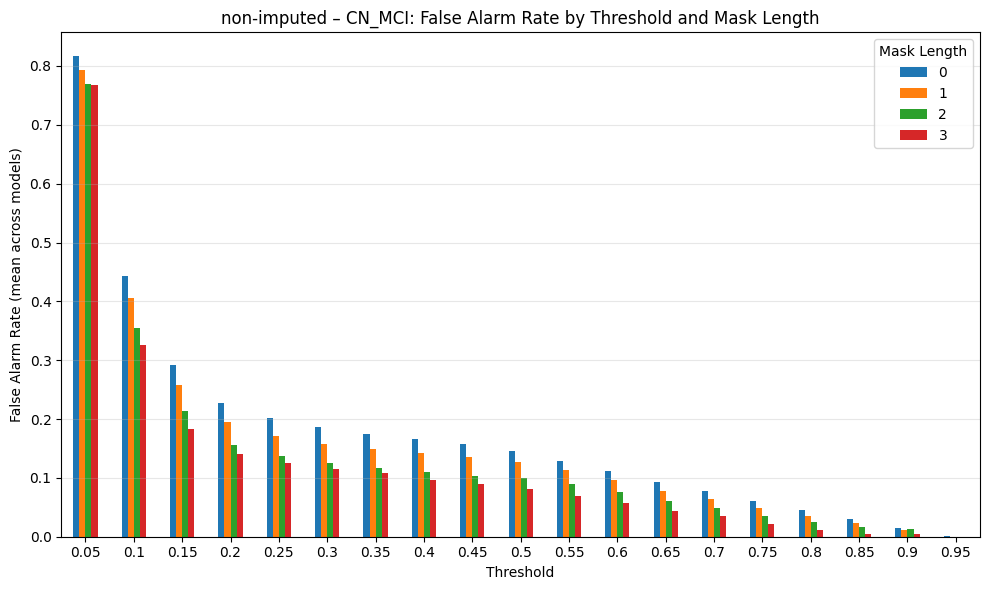


===== non‑imputed – MCI_AD: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.1 | 0.995 (0.990-1.000) | 0.086 (0.058-0.114) | 0.525 (0.517-0.532) | 0.947 (0.888-1.006) | 0.543 (0.530-0.556) | 0.687 (0.681-0.693) | 0.914 (0.886-0.942) | 20.003 (19.812-20.195) | 6.237 (6.023-6.451)
0.1 | 0.975 (0.970-0.979) | 0.295 (0.269-0.321) | 0.584 (0.575-0.592) | 0.920 (0.908-0.932) | 0.637 (0.625-0.649) | 0.730 (0.724-0.736) | 0.705 (0.679-0.731) | 17.106 (17.013-17.199) | 4.436 (4.357-4.515)
0.1 | 0.959 (0.952-0.967) | 0.412 (0.389-0.434) | 0.623 (0.615-0.632) | 0.910 (0.897-0.923) | 0.687 (0.677-0.698) | 0.755 (0.749-0.762) | 0.588 (0.566-0.611) | 17.514 (17.394-17.635) | 4.108 (3.943-4.272)
0.2 | 0.944 (0.933-0.956) | 0.523 (0.501-0.545) | 0.668 (0.658-0.677) | 0.903 (0.887-0.920) | 0.735 (0.725-0.745) | 0.782 (0.775-0.789) | 0.477 (0

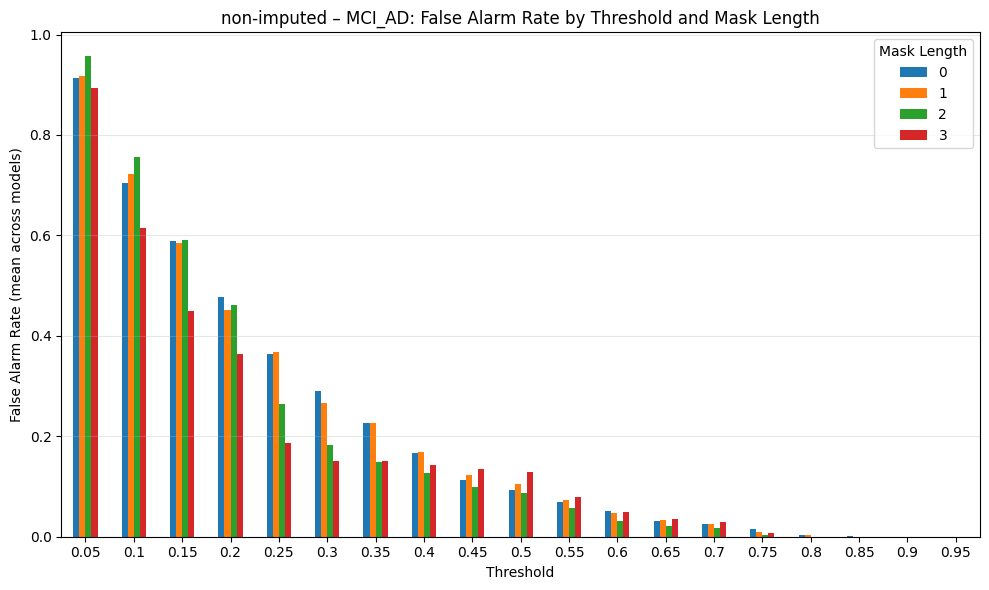


===== MICE‑imputed – CN_MCI: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.1 | 0.985 (0.983-0.988) | 0.113 (0.101-0.125) | 0.201 (0.199-0.203) | 0.969 (0.961-0.976) | 0.274 (0.264-0.283) | 0.334 (0.331-0.337) | 0.887 (0.875-0.899) | 43.026 (42.242-43.810) | 28.166 (27.404-28.928)
0.1 | 0.948 (0.944-0.952) | 0.500 (0.489-0.510) | 0.301 (0.297-0.306) | 0.977 (0.975-0.979) | 0.582 (0.574-0.591) | 0.457 (0.452-0.462) | 0.500 (0.490-0.511) | 39.426 (38.487-40.365) | 20.238 (19.501-20.975)
0.1 | 0.945 (0.941-0.949) | 0.695 (0.689-0.701) | 0.413 (0.408-0.418) | 0.982 (0.981-0.984) | 0.741 (0.736-0.746) | 0.575 (0.570-0.580) | 0.305 (0.299-0.311) | 34.400 (33.627-35.174) | 12.709 (12.234-13.185)
0.2 | 0.939 (0.935-0.944) | 0.771 (0.766-0.776) | 0.483 (0.477-0.489) | 0.983 (0.981-0.984) | 0.802 (0.798-0.806) | 0.638 (0.632-0.643) 

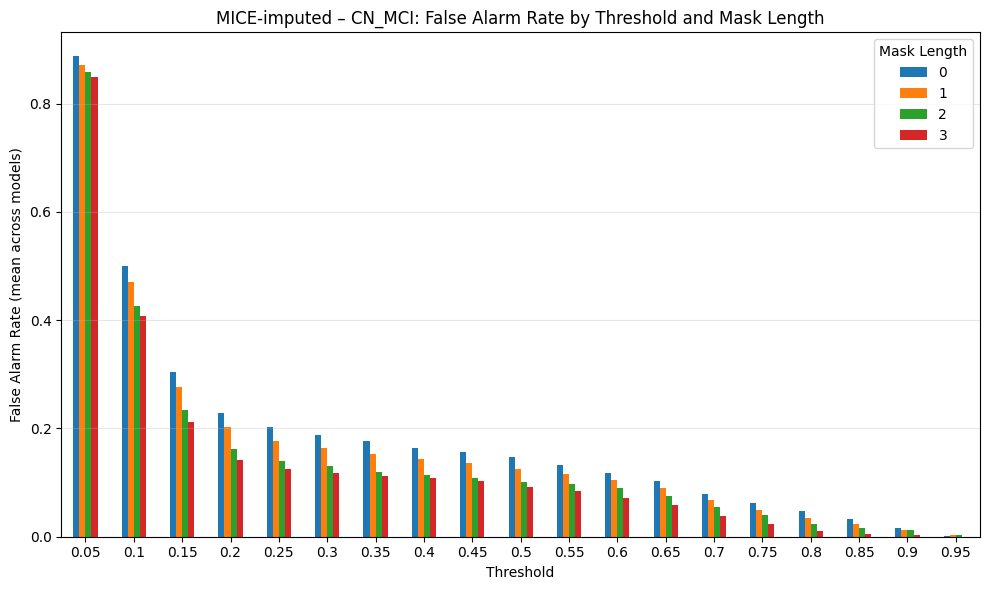


===== MICE‑imputed – MCI_AD: Summary metrics by threshold =====

Mask length = 0
Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.1 | 0.995 (0.993-0.996) | 0.100 (0.092-0.108) | 0.528 (0.526-0.531) | 0.950 (0.932-0.967) | 0.550 (0.546-0.554) | 0.690 (0.688-0.692) | 0.900 (0.892-0.908) | 19.745 (19.230-20.261) | 6.200 (5.953-6.447)
0.1 | 0.972 (0.968-0.975) | 0.251 (0.239-0.263) | 0.568 (0.564-0.573) | 0.897 (0.884-0.910) | 0.614 (0.607-0.620) | 0.717 (0.714-0.720) | 0.749 (0.737-0.761) | 18.665 (18.218-19.112) | 4.909 (4.624-5.193)
0.1 | 0.964 (0.960-0.969) | 0.391 (0.378-0.403) | 0.617 (0.612-0.622) | 0.916 (0.906-0.926) | 0.679 (0.673-0.686) | 0.752 (0.748-0.756) | 0.609 (0.597-0.622) | 18.252 (17.845-18.659) | 3.777 (3.493-4.061)
0.2 | 0.955 (0.950-0.960) | 0.531 (0.519-0.543) | 0.674 (0.669-0.680) | 0.922 (0.914-0.930) | 0.744 (0.738-0.751) | 0.790 (0.786-0.795) | 0.469 (

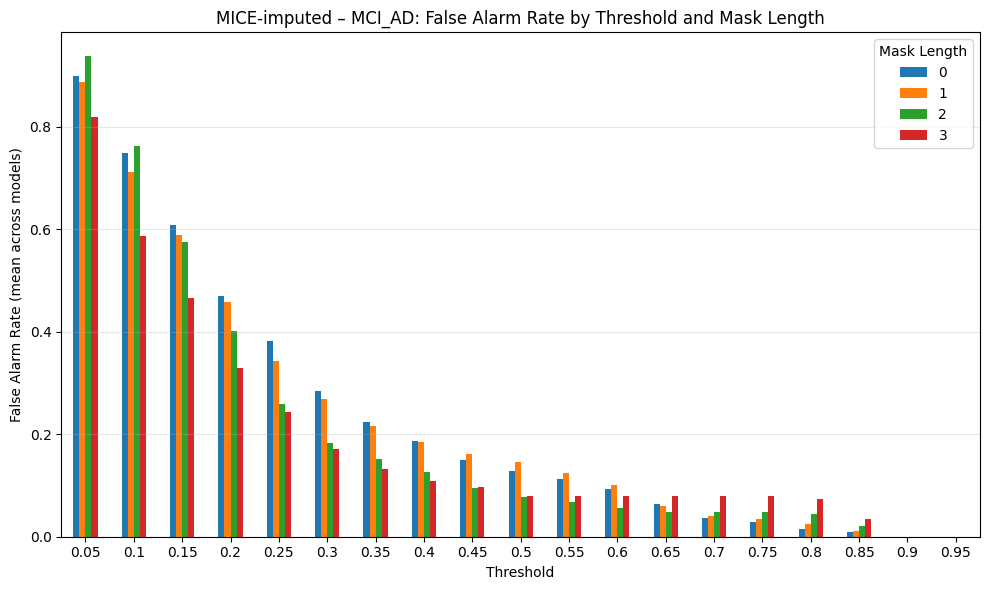

All summary statistics and bar charts generated.


In [14]:
# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
MASK_LENGTHS = [0, 1, 2, 3]

# We'll collect per‑model raw results for each (imputation, cohort)
all_raw_dfs = {}

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        # Nested-first loader: MICE-imputed uses the 10×10 bootstrap draws,
        # non-imputed uses the flat per-seed CSVs.
        prob_dict = load_cached_runs(cohort_dir)

        if not prob_dict:
            continue

        # Run grid to get per‑model metrics (now includes mean_net_lead_time)
        df_grid = run_grid(prob_dict, THRESHOLDS, MASK_LENGTHS)
        all_raw_dfs[(imp, cohort)] = df_grid

# ── Compute additional metrics per row ──
def add_metrics(df):
    # df has columns: model_key, threshold, mask_length, n_prog, n_detected, n_missed,
    # n_ctrl, n_false_alarm, sensitivity, specificity, mean_lead_time, mean_net_lead_time,
    # median_lead_time, median_net_lead_time, false_alarm_rate, plus counts
    df = df.copy()
    TP = df['n_detected']
    FN = df['n_missed']
    FP = df['n_false_alarm']
    TN = df['n_ctrl'] - FP

    df['PPV'] = TP / (TP + FP)
    df['NPV'] = TN / (TN + FN)
    df['accuracy'] = (TP + TN) / (df['n_prog'] + df['n_ctrl'])
    df['f1'] = 2 * (df['PPV'] * df['sensitivity']) / (df['PPV'] + df['sensitivity'])
    return df

# ── Aggregate and produce tables with 95% CI ──
# Include both early-only lead time and net lead time in the table
metrics_to_agg = ['sensitivity', 'specificity', 'PPV', 'NPV', 'accuracy', 'f1',
                  'false_alarm_rate', 'mean_lead_time', 'mean_net_lead_time']

for (imp, cohort), df_raw in all_raw_dfs.items():
    df_raw = add_metrics(df_raw)

    # Group by threshold and mask_length to compute mean, std, CI
    grouped = df_raw.groupby(['threshold', 'mask_length'])
    summary_rows = []
    for (thr, mask), group in grouped:
        row = {'threshold': thr, 'mask_length': mask}
        for m in metrics_to_agg:
            vals = group[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows)

    # Print a nice table for each mask_length
    print(f"\n===== {imp} – {cohort}: Summary metrics by threshold =====")
    # Note: Sensitivity, mean_lead_time, and mean_net_lead_time are invariant to mask_length
    # (because mask is not applied to progressors). They will be identical for all masks,
    # which serves as a sanity check.
    for mask in MASK_LENGTHS:
        sub = summary_df[summary_df['mask_length'] == mask].sort_values('threshold')
        if sub.empty:
            continue
        print(f"\nMask length = {mask}")
        # Extended header to include Net Lead
        header = ("Threshold | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | "
                  "Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)")
        print(header)
        for _, row in sub.iterrows():
            def fmt(m):
                return f"{row[f'{m}_mean']:.3f} ({row[f'{m}_ci_lower']:.3f}-{row[f'{m}_ci_upper']:.3f})" if not np.isnan(row[f'{m}_ci_lower']) else f"{row[f'{m}_mean']:.3f}"
            print(f"{row['threshold']:.1f} | {fmt('sensitivity')} | {fmt('specificity')} | "
                  f"{fmt('PPV')} | {fmt('NPV')} | {fmt('accuracy')} | {fmt('f1')} | "
                  f"{fmt('false_alarm_rate')} | {fmt('mean_lead_time')} | {fmt('mean_net_lead_time')}")

    # Bar chart for false alarm rate across thresholds, grouped by mask length
    fig, ax = plt.subplots(figsize=(10, 6))
    pivot = summary_df.pivot(index='threshold', columns='mask_length', values='false_alarm_rate_mean')
    pivot.plot(kind='bar', ax=ax, yerr=None, capsize=4, rot=0)
    ax.set_title(f"{imp} – {cohort}: False Alarm Rate by Threshold and Mask Length")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("False Alarm Rate (mean across models)")
    ax.legend(title="Mask Length")
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("All summary statistics and bar charts generated.")

# Include Everything Above in Supplemental Doc 


===== non‑imputed – CN_MCI: Dynamic mask (percentile=80%) =====
Threshold | Mask_len (mean±std) | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)
0.1 | 4.1±0.3 | 0.968 (0.958-0.978) | 0.263 (0.161-0.365) | 0.504 (0.463-0.545) | 0.906 (0.876-0.935) | 0.567 (0.509-0.625) | 0.661 (0.628-0.694) | 0.737 (0.635-0.839) | 42.884 (42.278-43.489) | 27.082 (25.968-28.197)
0.1 | 3.5±0.5 | 0.946 (0.943-0.949) | 0.696 (0.667-0.725) | 0.665 (0.644-0.687) | 0.953 (0.946-0.959) | 0.794 (0.779-0.809) | 0.781 (0.766-0.795) | 0.304 (0.275-0.333) | 39.214 (37.516-40.911) | 17.904 (15.926-19.882)
0.1 | 3.0±0.0 | 0.941 (0.938-0.944) | 0.818 (0.800-0.835) | 0.740 (0.721-0.758) | 0.962 (0.960-0.964) | 0.861 (0.850-0.872) | 0.828 (0.817-0.839) | 0.182 (0.165-0.200) | 34.137 (33.343-34.931) | 11.549 (10.773-12.325)
0.2 | 3.0±0.0 | 0.937 (0.933-0.941) | 0.860 (0.854-0.866) | 0.786 (0.779-0.793) | 0.961 (0.959-0.964)

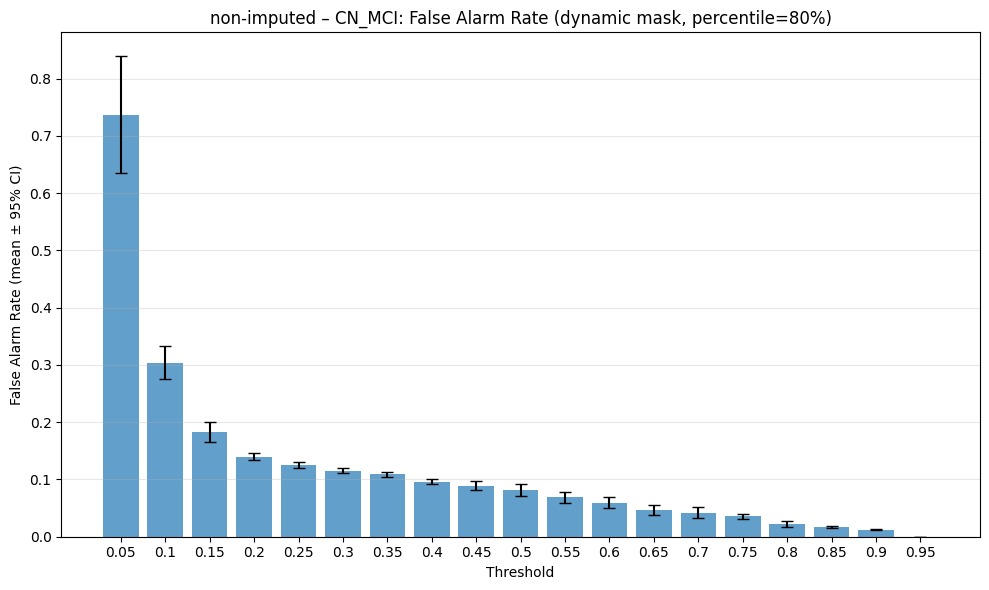

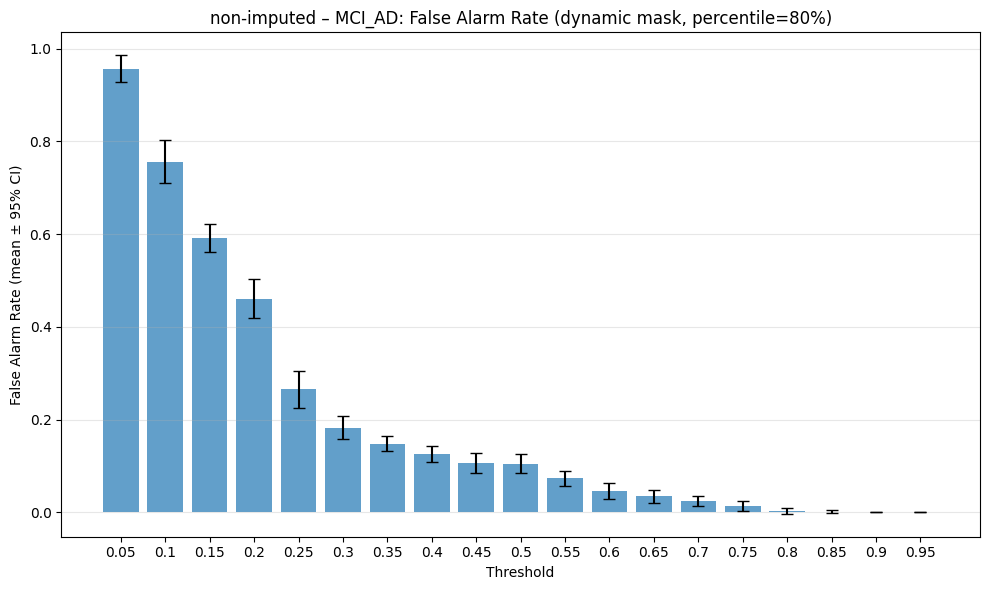

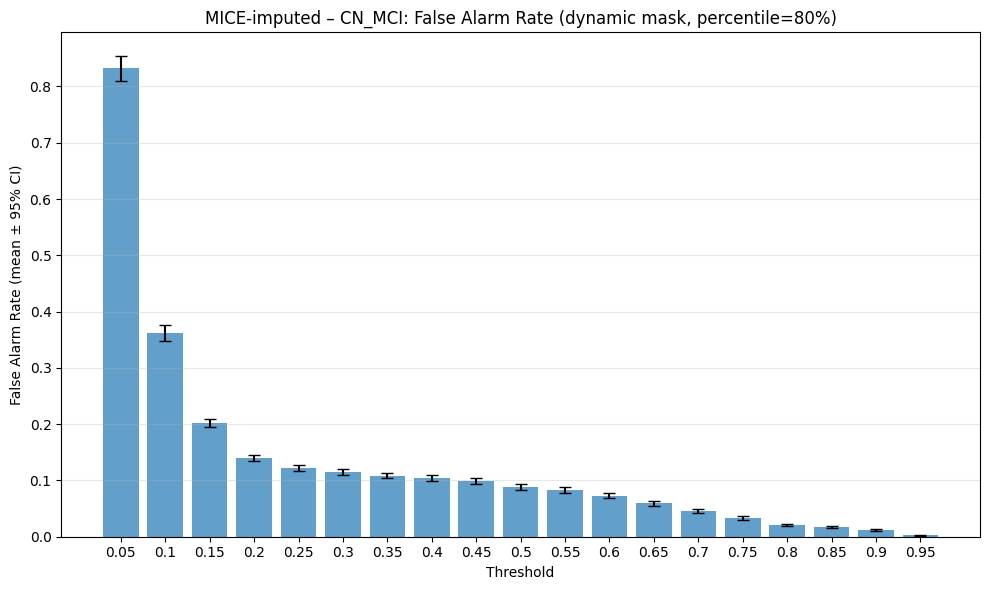

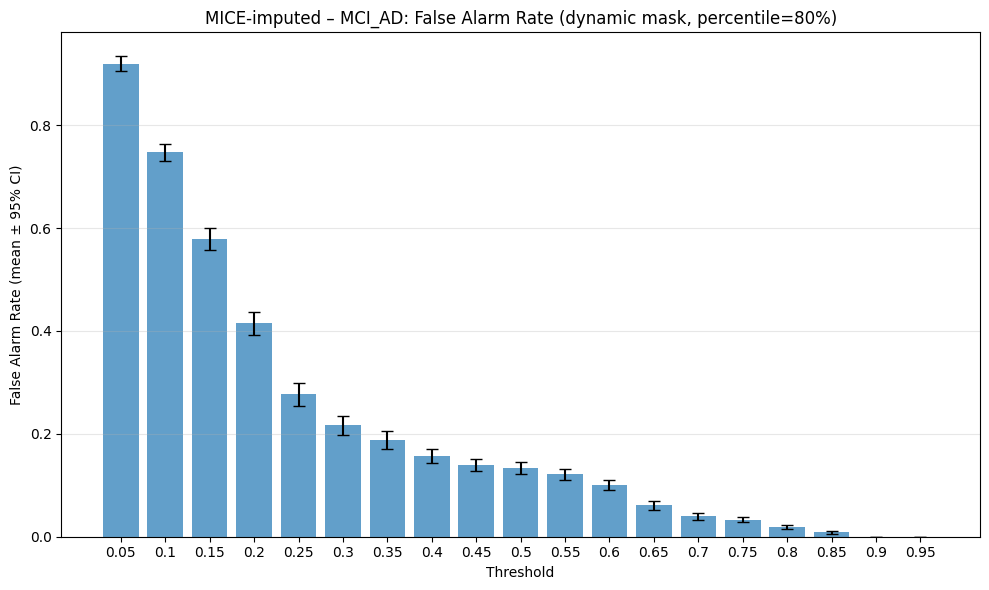

Dynamic mask analysis complete.


In [15]:
# =============================================================================
# Dynamic mask selection based on lead‑time distribution
# =============================================================================

# ── Reload leadtime module to ensure updated functions are used ──
import importlib
import leadtime
importlib.reload(leadtime)
from leadtime import mean_ci, analyze_run, get_conversion_month

# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

LEAD_TIME_PERCENTILE = 0.8   # 80th percentile of lead times -> exclude shortest 20%

# We'll collect per‑model results for each (imputation, cohort) with dynamic mask
dynamic_results = {}  # (imputation, cohort) -> list of rows per model and threshold

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        # Nested-first loader: MICE-imputed uses the 10×10 bootstrap draws,
        # non-imputed uses the flat per-seed CSVs.
        prob_dict = load_cached_runs(cohort_dir)

        if not prob_dict:
            continue

        rows = []
        for model_key, dfs in prob_dict.items():
            prog_df = dfs['prog']
            ctrl_df = dfs['ctrl']
            pred_cols = sorted([c for c in prog_df.columns if c.isdigit()], key=int)

            for thr in THRESHOLDS:
                # ---- Compute early lead times with mask_length=0 ----
                lead_times = []
                for _, row in prog_df.iterrows():
                    months = row['months_since_baseline']
                    progression = row['Progression']
                    true_conv_month = get_conversion_month(progression, months)
                    if true_conv_month is None:
                        continue
                    n_visits = len(months)
                    max_trunc = n_visits - 2  # mask=0
                    probs = []
                    for c in pred_cols:
                        if int(c) > max_trunc:
                            continue
                        if pd.notna(row[c]):
                            probs.append(row[c])
                    alarm_idx = None
                    for i, p in enumerate(probs):
                        if p >= thr:
                            alarm_idx = i
                            break
                    if alarm_idx is not None:
                        alarm_month = months[alarm_idx + 1]
                        lead = true_conv_month - alarm_month
                        if lead > 0:  # early detection
                            lead_times.append(lead)

                if len(lead_times) == 0:
                    mask_len = 0
                else:
                    target_lead = np.percentile(lead_times, LEAD_TIME_PERCENTILE * 100)
                    # # Count visits in last target_lead months for all subjects (prog + ctrl)
                    # all_subjects = list(prog_df.iterrows()) + list(ctrl_df.iterrows())
                    # visit_counts = []
                    # for _, row in all_subjects:
                    #     months = row['months_since_baseline']
                    #     last = months[-1]
                    #     count = sum(1 for m in months if m >= last - target_lead)
                    #     visit_counts.append(count)
                    # mask_len = int(np.median(visit_counts))

                    mask_len = int(round(target_lead / 15.9)) # divide by average visit interval 15.9 months
                    mask_len = max(0, mask_len)

                # Now run analyze_run with the dynamic mask (applied only to controls)
                res = analyze_run(prog_df, ctrl_df, thr, mask_len)
                rows.append({
                    'model_key': model_key,
                    'threshold': thr,
                    'mask_length': mask_len,
                    **res
                })

        # Convert to DataFrame
        df_dyn = pd.DataFrame(rows)
        dynamic_results[(imp, cohort)] = df_dyn

# ── Compute additional metrics (PPV, NPV, accuracy, F1) per model ──
def add_metrics(df):
    df = df.copy()
    TP = df['n_detected']
    FN = df['n_missed']
    FP = df['n_false_alarm']
    TN = df['n_ctrl'] - FP
    df['PPV'] = TP / (TP + FP)
    df['NPV'] = TN / (TN + FN)
    df['accuracy'] = (TP + TN) / (df['n_prog'] + df['n_ctrl'])
    df['f1'] = 2 * (df['PPV'] * df['sensitivity']) / (df['PPV'] + df['sensitivity'])
    return df

dynamic_with_metrics = {}
for (imp, cohort), df in dynamic_results.items():
    dynamic_with_metrics[(imp, cohort)] = add_metrics(df)

# ── Aggregate dynamic results with all metrics, including net lead time ──
metrics_all = ['sensitivity', 'specificity', 'PPV', 'NPV', 'accuracy', 'f1',
               'false_alarm_rate', 'mean_lead_time', 'mean_net_lead_time']
agg_dynamic_full = {}
for (imp, cohort), df in dynamic_with_metrics.items():
    summary_rows = []
    for thr in THRESHOLDS:
        sub = df[df['threshold'] == thr]
        if sub.empty:
            continue
        row = {'threshold': thr}
        mask_vals = sub['mask_length'].values
        row['mask_length_mean'] = np.mean(mask_vals)
        row['mask_length_std'] = np.std(mask_vals) if len(mask_vals) > 1 else np.nan
        for m in metrics_all:
            vals = sub[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        summary_rows.append(row)
    agg_dynamic_full[(imp, cohort)] = pd.DataFrame(summary_rows)

# ── Print full tables with both early and net lead times ──
for (imp, cohort), df in agg_dynamic_full.items():
    print(f"\n===== {imp} – {cohort}: Dynamic mask (percentile={LEAD_TIME_PERCENTILE:.0%}) =====")
    header = ("Threshold | Mask_len (mean±std) | Sens (95% CI) | Spec (95% CI) | PPV (95% CI) | NPV (95% CI) | "
              "Acc (95% CI) | F1 (95% CI) | FAR (95% CI) | Early Lead (95% CI) | Net Lead (95% CI)")
    print(header)
    for _, row in df.iterrows():
        def fmt(m):
            return f"{row[f'{m}_mean']:.3f} ({row[f'{m}_ci_lower']:.3f}-{row[f'{m}_ci_upper']:.3f})" if not np.isnan(row[f'{m}_ci_lower']) else f"{row[f'{m}_mean']:.3f}"
        mask_str = f"{row['mask_length_mean']:.1f}±{row['mask_length_std']:.1f}" if not np.isnan(row['mask_length_std']) else f"{row['mask_length_mean']:.1f}"
        print(f"{row['threshold']:.1f} | {mask_str} | {fmt('sensitivity')} | {fmt('specificity')} | "
              f"{fmt('PPV')} | {fmt('NPV')} | {fmt('accuracy')} | {fmt('f1')} | "
              f"{fmt('false_alarm_rate')} | {fmt('mean_lead_time')} | {fmt('mean_net_lead_time')}")

# ── Bar chart for false alarm rate from dynamic mask results ──
for (imp, cohort), df in agg_dynamic_full.items():
    if df.empty:
        continue
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(df['threshold'].astype(str), df['false_alarm_rate_mean'],
           yerr=[df['false_alarm_rate_mean'] - df['false_alarm_rate_ci_lower'],
                 df['false_alarm_rate_ci_upper'] - df['false_alarm_rate_mean']],
           capsize=4, alpha=0.7)
    ax.set_title(f"{imp} – {cohort}: False Alarm Rate (dynamic mask, percentile={LEAD_TIME_PERCENTILE:.0%})")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("False Alarm Rate (mean ± 95% CI)")
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

print("Dynamic mask analysis complete.")

In [16]:
# =============================================================================
# Save summary statistics to CSV files
# =============================================================================


# Ensure the output directory exists
OUTPUT_DIR = "lead_time results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 1. Fixed mask summary (from the first additional cell) ──
# The fixed mask summary DataFrames are stored in `summary_df` (or we can re‑create them if needed).
# However, in the first additional cell we used `summary_df` but it was overwritten per (imp, cohort).
# We need to store them in a dict while generating, but we can also recompute quickly from the raw grid results.

# We already have `all_raw_dfs` from the first cell, and we computed `summary_df` inside the loop.
# To be safe, we'll re‑run the aggregation for fixed mask and save.

# Re‑use the logic from the first additional cell, but we'll just save the DataFrames.
fixed_summaries = {}
for (imp, cohort), df_raw in all_raw_dfs.items():
    df_raw = add_metrics(df_raw)  # ensure metrics are added
    grouped = df_raw.groupby(['threshold', 'mask_length'])
    summary_rows = []
    for (thr, mask), group in grouped:
        row = {'threshold': thr, 'mask_length': mask}
        for m in metrics_to_agg:
            vals = group[m].dropna().values
            if len(vals) > 1:
                mean, lo, hi, std = mean_ci(vals)
                row[f'{m}_mean'] = mean
                row[f'{m}_ci_lower'] = lo
                row[f'{m}_ci_upper'] = hi
            elif len(vals) == 1:
                row[f'{m}_mean'] = vals[0]
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
            else:
                row[f'{m}_mean'] = np.nan
                row[f'{m}_ci_lower'] = np.nan
                row[f'{m}_ci_upper'] = np.nan
        summary_rows.append(row)
    fixed_summaries[(imp, cohort)] = pd.DataFrame(summary_rows)

# Save fixed mask summaries
for (imp, cohort), df in fixed_summaries.items():
    if not df.empty:
        out_path = os.path.join(OUTPUT_DIR, f"fixed_mask_summary_{imp}_{cohort}.csv")
        df.to_csv(out_path, index=False)
        print(f"Saved fixed mask summary to {out_path}")

# ── 2. Dynamic mask summary (from the second additional cell) ──
# We have `agg_dynamic_full` dict from the dynamic mask cell.
# Save each DataFrame.
for (imp, cohort), df in agg_dynamic_full.items():
    if not df.empty:
        out_path = os.path.join(OUTPUT_DIR, f"dynamic_mask_summary_{imp}_{cohort}_p{int(LEAD_TIME_PERCENTILE*100)}.csv")
        df.to_csv(out_path, index=False)
        print(f"Saved dynamic mask summary to {out_path}")

# ── 3. Optional: save the raw per‑model results for fixed and dynamic grids ──
# Fixed raw results are in `all_raw_dfs`; we can save them as well.
for (imp, cohort), df in all_raw_dfs.items():
    out_path = os.path.join(OUTPUT_DIR, f"fixed_mask_raw_{imp}_{cohort}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved fixed mask raw results to {out_path}")

# Dynamic raw results are in `dynamic_results`.
for (imp, cohort), df in dynamic_results.items():
    out_path = os.path.join(OUTPUT_DIR, f"dynamic_mask_raw_{imp}_{cohort}.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved dynamic mask raw results to {out_path}")

print("\nAll summary and raw data files have been saved to the 'lead_time results' directory.")

Saved fixed mask summary to lead_time results/fixed_mask_summary_non‑imputed_CN_MCI.csv
Saved fixed mask summary to lead_time results/fixed_mask_summary_non‑imputed_MCI_AD.csv
Saved fixed mask summary to lead_time results/fixed_mask_summary_MICE‑imputed_CN_MCI.csv
Saved fixed mask summary to lead_time results/fixed_mask_summary_MICE‑imputed_MCI_AD.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_non‑imputed_CN_MCI_p80.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_non‑imputed_MCI_AD_p80.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_MICE‑imputed_CN_MCI_p80.csv
Saved dynamic mask summary to lead_time results/dynamic_mask_summary_MICE‑imputed_MCI_AD_p80.csv
Saved fixed mask raw results to lead_time results/fixed_mask_raw_non‑imputed_CN_MCI.csv
Saved fixed mask raw results to lead_time results/fixed_mask_raw_non‑imputed_MCI_AD.csv
Saved fixed mask raw results to lead_time results/fixed_mask_raw_MICE‑imputed_CN_MCI

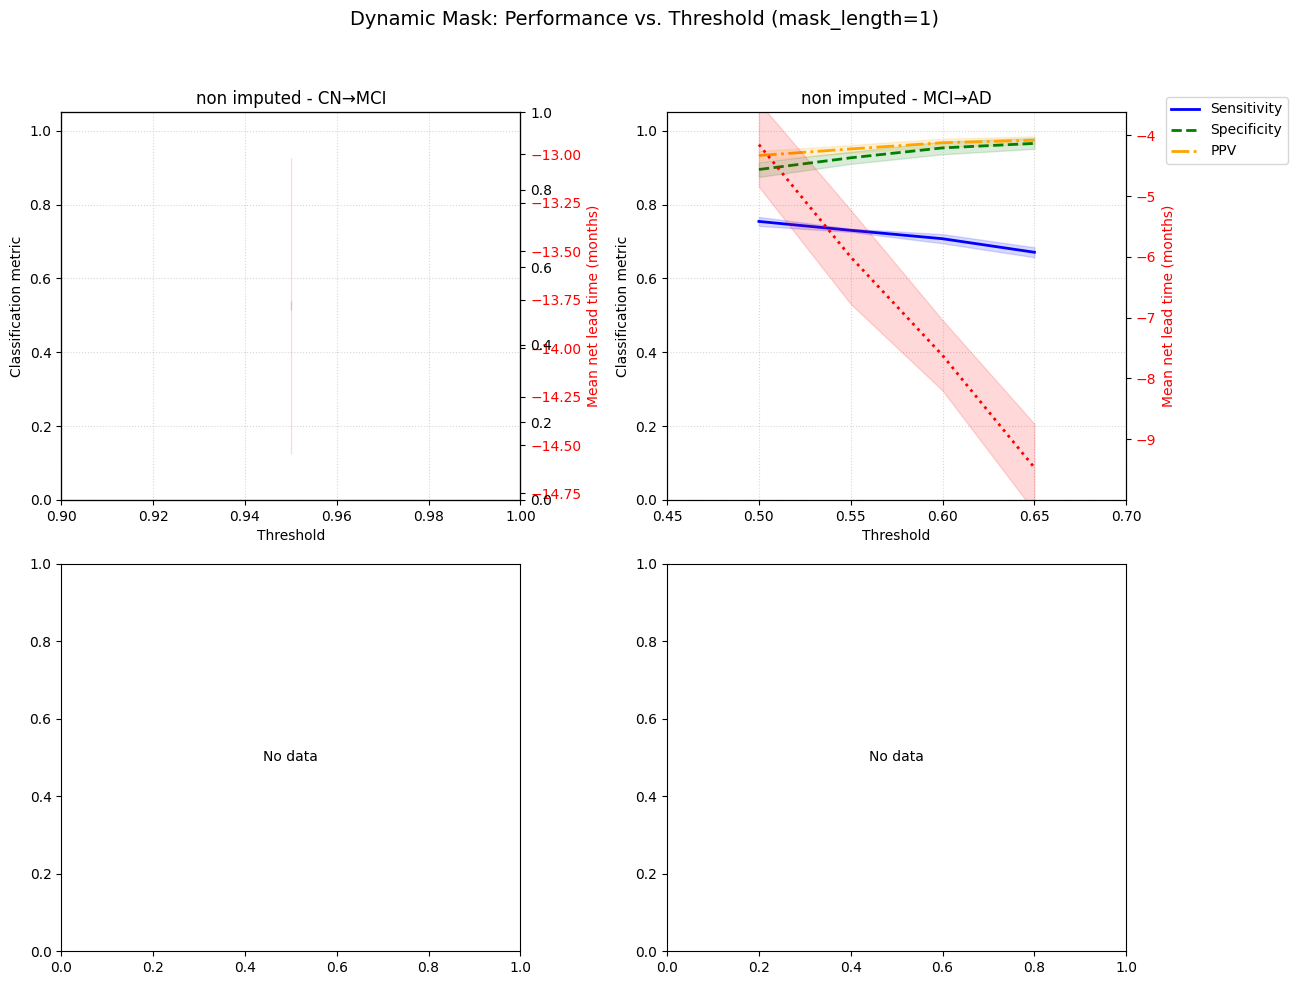

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. Load summary CSVs (same as before)
# ------------------------------------------------------------
summary_dir = Path("lead_time results")

files = {
    ("non_imputed", "CN_MCI"): "dynamic_mask_summary_non‑imputed_CN_MCI_p80.csv",
    ("non_imputed", "MCI_AD"): "dynamic_mask_summary_non‑imputed_MCI_AD_p80.csv",
    ("mice", "CN_MCI"): "dynamic_mask_summary_MICE‑imputed_CN_MCI_p80.csv",
    ("mice", "MCI_AD"): "dynamic_mask_summary_MICE‑imputed_MCI_AD_p80.csv",
}

data = {}
for (imp, cohort), fname in files.items():
    df = pd.read_csv(summary_dir / fname)
    # Keep only mask_length_mean == 1 (dominant case)
    df = df[df['mask_length_mean'] == 1.0].copy()
    data[(imp, cohort)] = df

# ------------------------------------------------------------
# 2. Updated plotting function
# ------------------------------------------------------------
def plot_metrics(data_dict, recommended=None):
    imps = ['non_imputed', 'mice']
    cohorts = ['CN_MCI', 'MCI_AD']
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=False)
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    
    # Define styles for classification metrics (primary axis)
    primary_metrics = {
        'sensitivity': {'label': 'Sensitivity', 'color': 'blue', 'linestyle': '-'},
        'specificity': {'label': 'Specificity', 'color': 'green', 'linestyle': '--'},
        'PPV': {'label': 'PPV', 'color': 'orange', 'linestyle': '-.'},
    }
    # Net lead time will be on secondary axis
    net_lead_style = {'label': 'Mean net lead time', 'color': 'red', 'linestyle': ':'}
    
    # Recommended thresholds (if not provided)
    if recommended is None:
        recommended = {
            ('non_imputed', 'CN_MCI'): 0.25,
            ('mice', 'CN_MCI'): 0.25,
            ('non_imputed', 'MCI_AD'): 0.35,
            ('mice', 'MCI_AD'): 0.35,
        }
    
    for i, imp in enumerate(imps):
        for j, cohort in enumerate(cohorts):
            ax = axes[i, j]
            df = data_dict.get((imp, cohort))
            if df is None or df.empty:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center')
                continue
            
            df = df.sort_values('threshold')
            x = df['threshold'].values
            
            # ---- Primary axis (classification metrics) ----
            for metric, style in primary_metrics.items():
                y = df[metric + '_mean'].values
                lo = df[metric + '_ci_lower'].values
                hi = df[metric + '_ci_upper'].values
                ax.plot(x, y, label=style['label'], color=style['color'],
                        linestyle=style['linestyle'], linewidth=2)
                ax.fill_between(x, lo, hi, color=style['color'], alpha=0.15)
            
            ax.set_xlabel('Threshold', fontsize=10)
            ax.set_ylabel('Classification metric', fontsize=10, color='black')
            ax.tick_params(axis='y', labelcolor='black')
            ax.grid(True, linestyle=':', alpha=0.5)
            ax.set_ylim(0, 1.05)   # classification metrics are 0-1
            
            # ---- Secondary axis (net lead time) ----
            ax2 = ax.twinx()
            y_net = df['mean_net_lead_time_mean'].values
            lo_net = df['mean_net_lead_time_ci_lower'].values
            hi_net = df['mean_net_lead_time_ci_upper'].values
            
            ax2.plot(x, y_net, label=net_lead_style['label'], color=net_lead_style['color'],
                     linestyle=net_lead_style['linestyle'], linewidth=2)
            ax2.fill_between(x, lo_net, hi_net, color=net_lead_style['color'], alpha=0.15)
            ax2.set_ylabel('Mean net lead time (months)', fontsize=10, color='red')
            ax2.tick_params(axis='y', labelcolor='red')
            
            # Let the secondary axis autoscale, but we can set a reasonable buffer
            y_min, y_max = y_net.min(), y_net.max()
            pad = (y_max - y_min) * 0.1 if y_max - y_min > 0 else 1
            ax2.set_ylim(y_min - pad, y_max + pad)
            
            # ---- X-axis limits based on actual data ----
            ax.set_xlim(x.min() - 0.05, x.max() + 0.05)
            
            # ---- Recommended threshold annotation ----
            rec = recommended.get((imp, cohort))
            if rec is not None and rec >= x.min() and rec <= x.max():
                ax.axvline(x=rec, color='black', linestyle=':', alpha=0.7, linewidth=1.5)
                # Place text at top of primary axis (y=1.02) to be visible
                ax.text(rec, 1.02, f'θ={rec}', rotation=90, va='bottom', ha='center',
                        fontsize=9, color='black', transform=ax.get_xaxis_transform())
            
            # ---- Title ----
            ax.set_title(f'{imp.replace("_", " ")} - {cohort.replace("_", "→")}', fontsize=12)
    
    # ---- Legend (placed outside the figure) ----
    # Collect handles from the first subplot's primary and secondary axes
    handles1, labels1 = axes[0,0].get_legend_handles_labels()
    handles2, labels2 = axes[0,0].twinx().get_legend_handles_labels()
    # Combine, avoiding duplicates
    all_handles = handles1 + handles2
    all_labels = labels1 + labels2
    fig.legend(all_handles, all_labels, loc='upper right', bbox_to_anchor=(1.0, 0.9),
               fontsize=10, frameon=True)
    
    fig.suptitle('Dynamic Mask: Performance vs. Threshold (mask_length=1)', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 0.92, 0.95])  # make room for legend on right
    return fig

# ------------------------------------------------------------
# 3. Generate and show the plot
# ------------------------------------------------------------
fig = plot_metrics(data)
plt.show()
# Optionally save: fig.savefig('dynamic_mask_metrics_vs_threshold.png', dpi=300, bbox_inches='tight')

## Experiment: How does prevalence correspond with mask length?
- NPV decreasing with longer mask length, is this supported by an expected decrease in prevalence? 

Prevalence vs NPV correlation (pooled across models & mask lengths):
  CN_MCI (threshold=0.25): r = -0.624, p = 0.0000  (n=440)
  MCI_AD (threshold=0.35): r = -0.873, p = 0.0000  (n=440)


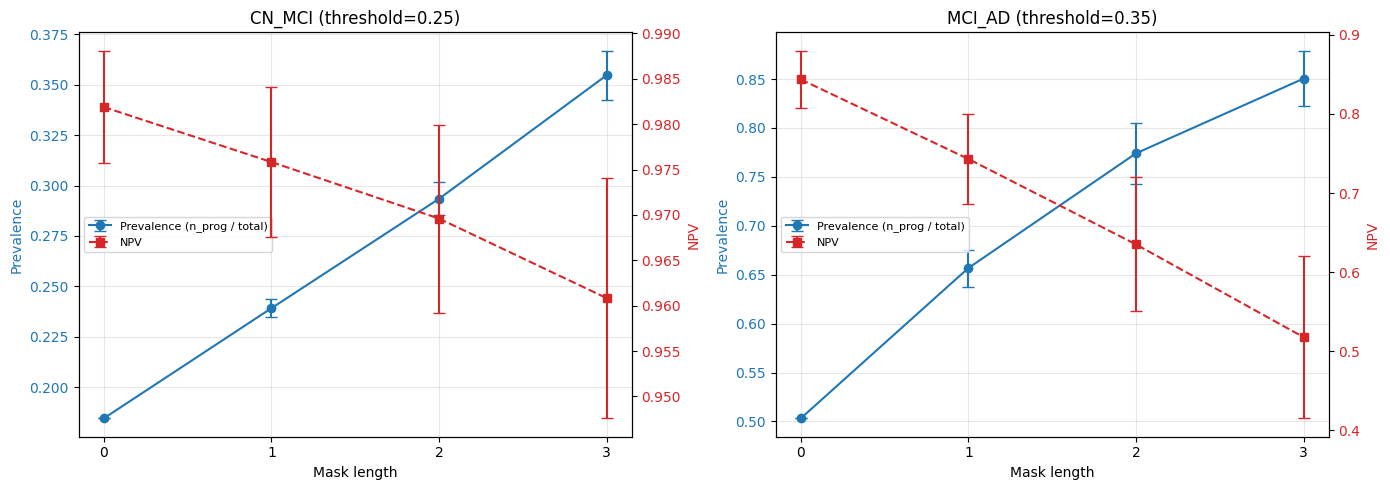

In [18]:
# =============================================================================
# Experiment: Prevalence (progressors / total) vs mask length, and its effect on NPV
# =============================================================================
CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
COHORT_THRESHOLDS = {"CN_MCI": 0.25, "MCI_AD": 0.35}
MASK_LENGTHS = [0, 1, 2, 3]

# Masking removes controls whose n_visits is too short (max_trunc < 0 in analyze_run),
# while progressors are always scored on their full truncation range. So n_ctrl should
# shrink as mask_length grows while n_prog stays fixed -> prevalence = n_prog/(n_prog+n_ctrl)
# should rise with mask_length. If NPV = TN/(TN+FN) tracks prevalence inversely, that
# confirms the expected Bayesian relationship (higher prevalence -> lower NPV, for
# roughly stable sensitivity/specificity).

rows = []
for imp in IMPUTATIONS:
    for cohort in COHORTS:
        thr = COHORT_THRESHOLDS[cohort]
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        # Nested-first loader: MICE-imputed uses the 10×10 bootstrap draws,
        # non-imputed uses the flat per-seed CSVs.
        for model_key, dfs in load_cached_runs(cohort_dir).items():
            prog_df = dfs['prog']
            ctrl_df = dfs['ctrl']

            for mask in MASK_LENGTHS:
                res = analyze_run(prog_df, ctrl_df, thr, mask)
                n_prog, n_ctrl = res['n_prog'], res['n_ctrl']
                if (n_prog + n_ctrl) == 0:
                    continue
                TN = n_ctrl - res['n_false_alarm']
                FN = res['n_missed']
                npv = TN / (TN + FN) if (TN + FN) > 0 else np.nan
                rows.append({
                    'imputation': imp, 'cohort': cohort, 'model_key': model_key,
                    'mask_length': mask, 'n_prog': n_prog, 'n_ctrl': n_ctrl,
                    'prevalence': n_prog / (n_prog + n_ctrl), 'NPV': npv,
                })

prev_df = pd.DataFrame(rows)

# ── Aggregate across models/imputations, per cohort × mask length ──
agg = prev_df.groupby(['cohort', 'mask_length']).agg(
    prevalence_mean=('prevalence', 'mean'), prevalence_std=('prevalence', 'std'),
    NPV_mean=('NPV', 'mean'), NPV_std=('NPV', 'std'),
).reset_index()

# ── Correlation between prevalence and NPV, pooled across models/masks per cohort ──
from scipy.stats import pearsonr
print("Prevalence vs NPV correlation (pooled across models & mask lengths):")
for cohort in COHORTS:
    sub = prev_df[prev_df['cohort'] == cohort].dropna(subset=['prevalence', 'NPV'])
    if len(sub) > 2:
        r, p = pearsonr(sub['prevalence'], sub['NPV'])
        print(f"  {cohort} (threshold={COHORT_THRESHOLDS[cohort]}): r = {r:.3f}, p = {p:.4f}  (n={len(sub)})")

# ── Plot: prevalence and NPV vs mask length, per cohort ──
fig, axes = plt.subplots(1, len(COHORTS), figsize=(7 * len(COHORTS), 5))
for ax, cohort in zip(axes, COHORTS):
    sub = agg[agg['cohort'] == cohort].sort_values('mask_length')
    ax2 = ax.twinx()

    l1 = ax.errorbar(sub['mask_length'], sub['prevalence_mean'], yerr=sub['prevalence_std'],
                      marker='o', color='#1f77b4', capsize=4, label='Prevalence (n_prog / total)')
    l2 = ax2.errorbar(sub['mask_length'], sub['NPV_mean'], yerr=sub['NPV_std'],
                       marker='s', linestyle='--', color='#d62728', capsize=4, label='NPV')

    ax.set_xlabel('Mask length')
    ax.set_ylabel('Prevalence', color='#1f77b4')
    ax2.set_ylabel('NPV', color='#d62728')
    ax.tick_params(axis='y', labelcolor='#1f77b4')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    ax.set_xticks(MASK_LENGTHS)
    ax.set_title(f"{cohort} (threshold={COHORT_THRESHOLDS[cohort]})")
    ax.grid(True, alpha=0.3)

    lines = [l1, l2]
    ax.legend(lines, [l.get_label() for l in lines], loc='center left', fontsize=8)

plt.tight_layout()
plt.savefig("prevalence_vs_mask_length_npv.png", dpi=300, bbox_inches='tight')
plt.show()


In [2]:
# For the following specifications (CN->MCI: mask length 3, threshold 0.25; MCI->AD: mask length 2, threshold 0.30), compute Sensitivity	Specificity	PPV	NPV	Accuracy	F1	False Alarm Rate	Mean Lead Time	Net Lead Time	ROC-AUC	PR-AUC with their CI's. 
# ── Specified threshold/mask metrics + 95% CI, exported to an Excel-ready CSV ──
# CN→MCI: threshold 0.25, mask 3   |   MCI→AD: threshold 0.30, mask 2
from leadtime import analyze_run, mean_ci

CACHE_ROOT = "leadtime_prob_cache"
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
SPECS = {"CN_MCI": (0.25, 3), "MCI_AD": (0.30, 2)}

def run_metrics(res):
    TP = res['n_detected']; FN = res['n_missed']; FP = res['n_false_alarm']
    TN = res['n_ctrl'] - FP
    ppv = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    npv = TN / (TN + FN) if (TN + FN) > 0 else np.nan
    acc = (TP + TN) / (res['n_prog'] + res['n_ctrl']) if (res['n_prog'] + res['n_ctrl']) > 0 else np.nan
    f1 = 2 * ppv * res['sensitivity'] / (ppv + res['sensitivity']) if (ppv + res['sensitivity']) > 0 else np.nan
    return {'sensitivity': res['sensitivity'], 'specificity': res['specificity'],
            'PPV': ppv, 'NPV': npv, 'accuracy': acc, 'f1': f1,
            'false_alarm_rate': res['false_alarm_rate'],
            'mean_lead_time': res['mean_lead_time'],
            'mean_net_lead_time': res['mean_net_lead_time'],
            'roc_auc': res['roc_auc'], 'pr_auc': res['pr_auc']}

rows = []
for imp in IMPUTATIONS:
    for cohort, (thr, mask) in SPECS.items():
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing: {cohort_dir}")
            continue
        for run_key, dfs in load_cached_runs(cohort_dir).items():
            res = analyze_run(dfs['prog'], dfs['ctrl'], thr, mask)
            if res['n_prog'] == 0:
                continue
            rows.append({'cohort': cohort, 'imputation': imp, 'run': run_key, **run_metrics(res)})

df = pd.DataFrame(rows)

# Aggregate mean + 95% CI across runs
NICE = {'sensitivity': 'Sensitivity', 'specificity': 'Specificity', 'PPV': 'PPV',
        'NPV': 'NPV', 'accuracy': 'Accuracy', 'f1': 'F1',
        'false_alarm_rate': 'FAR', 'mean_lead_time': 'Mean_LT', 'mean_net_lead_time': 'Net_LT',
        'roc_auc': 'ROC_AUC', 'pr_auc': 'PR_AUC'}

records = []
for (cohort, imp), grp in df.groupby(['cohort', 'imputation']):
    rec = {'Group': cohort, 'Imputation': imp, 'n_runs': len(grp)}
    for key, nice in NICE.items():
        vals = grp[key].dropna().values
        mean, lo, hi, _ = mean_ci(vals)
        rec[f'{nice}_mean'] = mean
        rec[f'{nice}_lo'] = lo
        rec[f'{nice}_hi'] = hi
    records.append(rec)

out = pd.DataFrame(records)
col_order = ['Group', 'Imputation', 'n_runs']
for nice in NICE.values():
    col_order += [f'{nice}_mean', f'{nice}_lo', f'{nice}_hi']
out = out[col_order].sort_values(['Group', 'Imputation'])

out.to_csv('leadtime_specified_metrics.csv', index=False)
display(out)
print("Wrote leadtime_specified_metrics.csv")

,Group,Imputation,n_runs,Sensitivity_mean,Sensitivity_lo,Sensitivity_hi,Specificity_mean,Specificity_lo,Specificity_hi,PPV_mean,...,Mean_LT_hi,Net_LT_mean,Net_LT_lo,Net_LT_hi,ROC_AUC_mean,ROC_AUC_lo,ROC_AUC_hi,PR_AUC_mean,PR_AUC_lo,PR_AUC_hi
0,CN_MCI,MICE‑imputed,100,0.935630,0.930949,0.940312,0.874299,0.869786,0.878812,0.804387,...,33.363203,9.535994,9.144876,9.927111,0.949114,0.946086,0.952142,0.948315,0.945510,0.951120
1,CN_MCI,non‑imputed,10,0.927731,0.922662,0.932800,0.874194,0.868799,0.879588,0.801859,...,33.262895,9.423245,9.201170,9.645321,0.946981,0.945406,0.948556,0.948253,0.947512,0.948993
2,MCI_AD,MICE‑imputed,100,0.886076,0.878673,0.893479,0.816963,0.798760,0.835167,0.944103,...,18.012663,1.515733,1.202797,1.828670,0.916297,0.909855,0.922738,0.974704,0.972549,0.976858
3,MCI_AD,non‑imputed,10,0.884810,0.873969,0.895651,0.817391,0.792857,0.841925,0.943438,...,18.220086,2.851754,2.445754,3.257754,0.920859,0.917176,0.924542,0.977746,0.976725,0.978766


Wrote leadtime_specified_metrics.csv


In [3]:
# ── Wide paper table (image layout): reshape leadtime_specified_metrics.csv
#    into CN→MCI / MCI→AD × Imputed (No / Yes). F.A.R. excluded per request. ──
import os
import pandas as pd

SRC = "leadtime_specified_metrics.csv"
OUT_DIR = os.path.join("charts", "paper")
os.makedirs(OUT_DIR, exist_ok=True)

# Row labels in the order they appear in the paper table.
METRIC_ROWS = [
    ("ROC_AUC",     "ROC-AUC"),
    ("PR_AUC",      "PR-AUC"),
    ("Sensitivity", "Sensitivity"),
    ("Specificity", "Specificity"),
    ("PPV",         "PPV"),
    ("NPV",         "NPV"),
    ("Accuracy",    "Accuracy"),
    ("F1",          "F1"),
]

GROUP_LABELS = {"CN_MCI": "CN to MCI", "MCI_AD": "MCI to AD"}
GROUP_ORDER  = ["CN_MCI", "MCI_AD"]

long_df = pd.read_csv(SRC)

def is_mice(imp):
    return "MICE" in imp

def col_label(group, imp):
    return f"{GROUP_LABELS[group]} — {'Yes' if is_mice(imp) else 'No'}"

def fmt(mean, lo, hi):
    return f"{mean:.3f} ({lo:.3f}–{hi:.3f})"

# Build the (group, imputation) column list in image order: No then Yes.
columns = []
for g in GROUP_ORDER:
    sub = long_df[long_df["Group"] == g]
    assert len(sub) == 2, f"Expected 2 imputations for {g}, got {len(sub)}"
    for imp in sorted(sub["Imputation"], key=is_mice):
        columns.append((g, imp))

table = {}
for g, imp in columns:
    row = long_df[(long_df["Group"] == g) & (long_df["Imputation"] == imp)].iloc[0]
    col = col_label(g, imp)
    for src, nice in METRIC_ROWS:
        table.setdefault(nice, {})[col] = fmt(row[f"{src}_mean"], row[f"{src}_lo"], row[f"{src}_hi"])

wide = pd.DataFrame(table).T
wide = wide[[col_label(g, imp) for g, imp in columns]]

out_path = os.path.join(OUT_DIR, "classification_metrics_table.csv")
wide.to_csv(out_path, index_label="Metric")
display(wide)
print(f"Saved -> {out_path}")

,CN to MCI — No,CN to MCI — Yes,MCI to AD — No,MCI to AD — Yes
ROC-AUC,0.947 (0.945–0.949),0.949 (0.946–0.952),0.921 (0.917–0.925),0.916 (0.910–0.923)
PR-AUC,0.948 (0.948–0.949),0.948 (0.946–0.951),0.978 (0.977–0.979),0.975 (0.973–0.977)
Sensitivity,0.928 (0.923–0.933),0.936 (0.931–0.940),0.885 (0.874–0.896),0.886 (0.879–0.893)
Specificity,0.874 (0.869–0.880),0.874 (0.870–0.879),0.817 (0.793–0.842),0.817 (0.799–0.835)
PPV,0.802 (0.795–0.808),0.804 (0.798–0.810),0.943 (0.936–0.950),0.944 (0.939–0.950)
NPV,0.957 (0.954–0.959),0.961 (0.959–0.964),0.675 (0.655–0.695),0.679 (0.661–0.697)
Accuracy,0.893 (0.890–0.896),0.896 (0.893–0.899),0.870 (0.861–0.878),0.871 (0.864–0.878)
F1,0.860 (0.857–0.864),0.865 (0.860–0.869),0.913 (0.907–0.919),0.914 (0.909–0.919)


Saved -> charts/paper/classification_metrics_table.csv


In [3]:
import pandas as pd, ast

def load(path):
    df = pd.read_csv(path)
    df['msb'] = df['months_since_baseline'].apply(ast.literal_eval)
    df['first_eval'] = df['msb'].apply(lambda m: m[1])     # month of 2nd visit (first prefix)
    df['obs_span']  = df['msb'].apply(lambda m: m[-1])     # baseline -> final visit (full follow-up)
    return df

for name, path, mask in [('CN_MCI', 'datasets/Dataset_v2_1/lead_time_CN.csv', 3),
                         ('MCI_AD', 'datasets/Dataset_v2_1/lead_time_MCI_AD.csv', 2)]:
    d = load(path)
    prog = d[d.Prog_ID == 1].copy()
    ctrl = d[(d.Prog_ID == 0) & (d.n_visits >= mask + 2)].copy()   # controls actually scored

    prog['last_eval'] = prog.msb.apply(lambda m: m[-1])            # progressors: full record
    ctrl['last_eval'] = ctrl.msb.apply(lambda m: m[-(mask + 1)])   # controls: masked endpoint
    ev = pd.concat([prog, ctrl])

    print(name, '| n_prog', len(prog), '| n_ctrl', len(ctrl))
    print('  follow-up span (all subjects): mean %.1f  median %.1f  range %.1f-%.1f'
          % (d.obs_span.mean(), d.obs_span.median(), d.obs_span.min(), d.obs_span.max()))
    print('  first eval month (2nd visit):  mean %.1f  range %.1f-%.1f'
          % (ev.first_eval.mean(), ev.first_eval.min(), ev.first_eval.max()))
    print('  last evaluated month:          mean %.1f  median %.1f'
          % (ev.last_eval.mean(), ev.last_eval.median()))

CN_MCI | n_prog 119 | n_ctrl 217
  follow-up span (all subjects): mean 56.1  median 48.5  range 9.1-214.1
  first eval month (2nd visit):  mean 15.6  range 7.3-65.1
  last evaluated month:          mean 51.6  median 47.3
MCI_AD | n_prog 79 | n_ctrl 23
  follow-up span (all subjects): mean 42.7  median 34.8  range 9.1-126.1
  first eval month (2nd visit):  mean 15.1  range 9.9-46.2
  last evaluated month:          mean 46.6  median 38.7


### Brier Score Calculation

In [6]:

# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
COHORTS = ["CN_MCI", "MCI_AD"]
MASK_LENGTH = [3, 2]
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]


for imp in IMPUTATIONS:
    for i_cohort, cohort in enumerate(COHORTS):
        # first element for prediction-weighted
        # second for subject-weighted
        overall = [[],[]]
        ps = [[],[]]
        ng = [[],[]]

        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            print(f"Missing cache dir: {cohort_dir}")
            continue

        prob_dict = load_cached_runs(cohort_dir)

        for key, dfs in prob_dict.items():
            # first element for prediction-weighted
            # second for subject-weighted
            sum_ps = [[],[]]
            sum_ng = [[],[]]


            prog = dfs['prog']
            ctrl = dfs['ctrl']

            for _, row in prog.iterrows():
                sum = []
                n_visits = len(row['months_since_baseline'])
                for i in range(n_visits-1):
                    c = str(i)
                    if c in row and pd.notna(row[c]):
                        brier = (1-row[c])**2
                        sum_ps[0].append(brier)
                        sum.append(brier)
                sum_ps[1].append(np.mean(sum))

            for _, row in ctrl.iterrows():
                sum = []
                n_visits = len(row['months_since_baseline'])
                # Apply mask to controls
                max_trunc = n_visits - MASK_LENGTH[i_cohort] - 2
                if max_trunc < 0:
                    continue
                for i in range(max_trunc + 1):
                    c = str(i)
                    if c in row and pd.notna(row[c]):
                        brier = row[c]**2
                        sum_ng[0].append(brier)
                        sum.append(brier)
                sum_ng[1].append(np.mean(sum))

            for k in [0,1]:
                ps[k].append(np.mean(sum_ps[k]))
                ng[k].append(np.mean(sum_ng[k]))
                overall[k].append(np.mean(sum_ps[k]+sum_ng[k]))
            
        def format(x):
            metrics = [
            (overall[x], "      Overall"),
            (ps[x], "positive only"),
            (ng[x], "negative only"),
            ]
            for s, output in metrics:
                mean, l, h, _ = mean_ci(s)
                print(f"                {output}: {round(mean,4)} ({round(l,4)}--{round(h,4)})")
        print(f"\n{imp} - {cohort}")
        print(f"    prediction-weighted:")
        format(0)
        print(f"    subject-weighted:")
        format(1)



non‑imputed - CN_MCI
    prediction-weighted:
                      Overall: 0.1655 (0.1625--0.1684)
                positive only: 0.3346 (0.3257--0.3435)
                negative only: 0.024 (0.0218--0.0261)
    subject-weighted:
                      Overall: 0.1279 (0.1261--0.1298)
                positive only: 0.3129 (0.3037--0.322)
                negative only: 0.0265 (0.0241--0.0289)

non‑imputed - MCI_AD
    prediction-weighted:
                      Overall: 0.1725 (0.1697--0.1753)
                positive only: 0.1977 (0.1939--0.2015)
                negative only: 0.052 (0.0475--0.0565)
    subject-weighted:
                      Overall: 0.1975 (0.1933--0.2017)
                positive only: 0.2428 (0.237--0.2486)
                negative only: 0.042 (0.0394--0.0446)

MICE‑imputed - CN_MCI
    prediction-weighted:
                      Overall: 0.1653 (0.1623--0.1683)
                positive only: 0.3279 (0.3221--0.3338)
                negative only: 0.028 (0.0269--0.0

,imputation,cohort,offset,visit_label,n_observations,n_runs,brier_mean,brier_ci_lower,brier_ci_upper,brier_std
0,MICE‑imputed,CN_MCI,-2,n-2,5284,100,0.668907,0.659244,0.678570,0.048698
1,MICE‑imputed,CN_MCI,-1,n-1,8176,100,0.573378,0.564992,0.581765,0.042267
2,MICE‑imputed,CN_MCI,0,n+0,11900,100,0.142632,0.137243,0.148022,0.027161
3,MICE‑imputed,CN_MCI,1,n+1,7004,100,0.072645,0.067994,0.077296,0.023439
8,non‑imputed,CN_MCI,-2,n-2,520,10,0.671306,0.656216,0.686396,0.021095
9,non‑imputed,CN_MCI,-1,n-1,810,10,0.586446,0.572221,0.600671,0.019885
10,non‑imputed,CN_MCI,0,n+0,1190,10,0.150466,0.142703,0.158228,0.010852
11,non‑imputed,CN_MCI,1,n+1,700,10,0.076752,0.072250,0.081253,0.006292
4,MICE‑imputed,MCI_AD,-2,n-2,808,100,0.443219,0.428092,0.458345,0.076234
5,MICE‑imputed,MCI_AD,-1,n-1,2743,100,0.454186,0.442210,0.466162,0.060356


,imputation,cohort,offset,visit_label,n_observations,n_runs,brier_mean,brier_ci_lower,brier_ci_upper,brier_std
0,MICE‑imputed,CN_MCI,-9,n-9,99,66,0.821540,0.812983,0.830096,0.034806
1,MICE‑imputed,CN_MCI,-8,n-8,293,96,0.576055,0.531310,0.620800,0.220835
2,MICE‑imputed,CN_MCI,-7,n-7,1021,100,0.694295,0.675879,0.712711,0.092812
3,MICE‑imputed,CN_MCI,-6,n-6,1641,100,0.743029,0.729516,0.756542,0.068101
4,MICE‑imputed,CN_MCI,-5,n-5,2699,100,0.751864,0.741474,0.762253,0.052359
5,MICE‑imputed,CN_MCI,-4,n-4,3507,100,0.657443,0.644658,0.670227,0.064433
6,MICE‑imputed,CN_MCI,-3,n-3,5284,100,0.668907,0.659244,0.678570,0.048698
7,MICE‑imputed,CN_MCI,-2,n-2,8176,100,0.573378,0.564992,0.581765,0.042267
8,MICE‑imputed,CN_MCI,-1,n-1,11900,100,0.142632,0.137243,0.148022,0.027161
9,MICE‑imputed,CN_MCI,0,n+0,7004,100,0.072645,0.067994,0.077296,0.023439


C:\Users\lz000\AppData\Local\Temp\ipykernel_12596\34755711.py:244: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(title="Imputation")


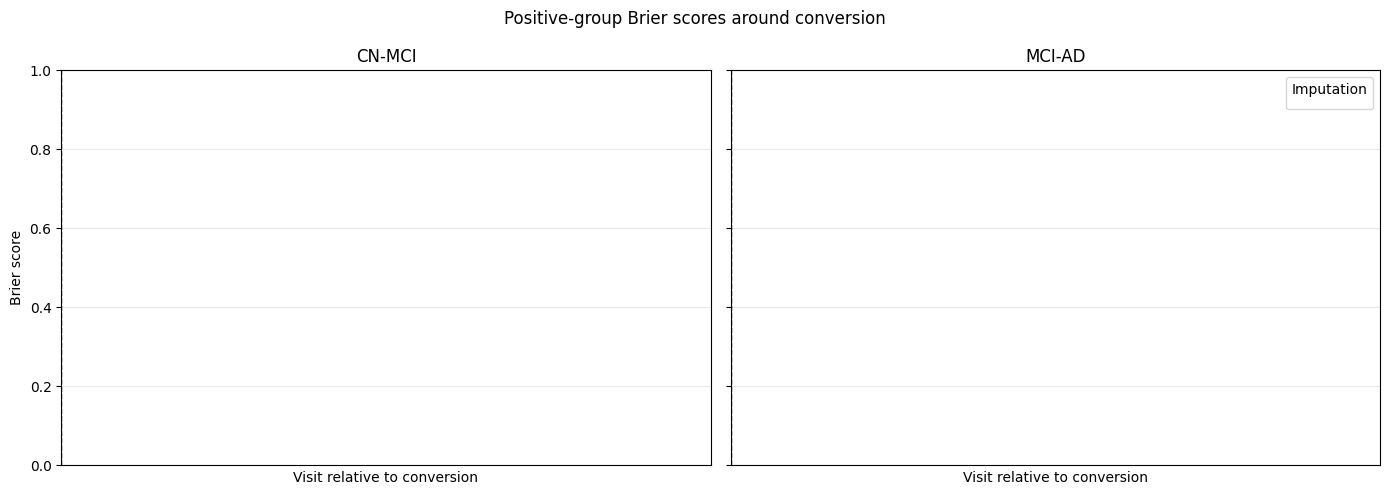

In [ ]:

# ── Config ────────────────────────────────────────────────────────────────
CACHE_ROOT = "leadtime_prob_cache"
COHORTS = ["CN_MCI", "MCI_AD"]
MASK_LENGTH = [3, 2]
IMPUTATIONS = ["non‑imputed", "MICE‑imputed"]
COHORTS = ["CN_MCI", "MCI_AD"]
# =============================================================================
# Positive-group Brier scores around the conversion visit
# Offsets: n-2, n-1, n, n+1
# =============================================================================

OFFSETS = [-2, -1, 0, 1]
brier_rows = []

for imp in IMPUTATIONS:
    for cohort in COHORTS:
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            continue

        for run_key, dfs in load_cached_runs(cohort_dir).items():
            prog_df = dfs["prog"]

            for subject_id, row in prog_df.iterrows():
                months = row["months_since_baseline"]
                progression = row["Progression"]

                conversion_month = get_conversion_month(progression, months)
                if conversion_month is None:
                    continue

                # Visit n = first visit at or after the true conversion month.
                conversion_visit = next(
                    (i for i, month in enumerate(months)
                     if month >= conversion_month),
                    None
                )
                if conversion_visit is None:
                    continue

                subject_scores = {}

                for offset in OFFSETS:
                    visit_idx = conversion_visit + offset

                    # Predictions c=0,1,... correspond to visits 1,2,...
                    pred_idx = visit_idx - 1
                    pred_col = str(pred_idx)

                    if visit_idx < 1 or pred_col not in row:
                        continue
                    if pd.isna(row[pred_col]):
                        continue

                    probability = float(row[pred_col])
                    brier = (1.0 - probability) ** 2  # positive-group target = 1

                    brier_rows.append({
                        "imputation": imp,
                        "cohort": cohort,
                        "run": run_key,
                        "subject_id": subject_id,
                        "offset": offset,
                        "visit_label": f"n{offset:+d}",
                        "visit_index": visit_idx,
                        "visit_month": months[visit_idx],
                        "conversion_month": conversion_month,
                        "predicted_probability": probability,
                        "brier_score": brier,
                    })

brier_positive_df = pd.DataFrame(brier_rows)

# Subject-weighted scores: average repeated observations within each subject first.
subject_weighted = (
    brier_positive_df
    .groupby(["imputation", "cohort", "run", "subject_id", "offset"], as_index=False)
    ["brier_score"].mean()
)

# Summarize across cached runs.
summary_rows = []
for (imp, cohort, offset), group in subject_weighted.groupby(
    ["imputation", "cohort", "offset"]
):
    run_means = group.groupby("run")["brier_score"].mean().dropna().values
    mean, ci_low, ci_high, std = mean_ci(run_means)

    prediction_values = brier_positive_df[
        (brier_positive_df["imputation"] == imp) &
        (brier_positive_df["cohort"] == cohort) &
        (brier_positive_df["offset"] == offset)
    ]["brier_score"].dropna().values

    summary_rows.append({
        "imputation": imp,
        "cohort": cohort,
        "offset": offset,
        "visit_label": f"n{offset:+d}",
        "n_observations": len(prediction_values),
        "n_runs": len(run_means),
        "brier_mean": mean,
        "brier_ci_lower": ci_low,
        "brier_ci_upper": ci_high,
        "brier_std": std,
    })

brier_positive_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["cohort", "imputation", "offset"])
)

display(brier_positive_summary)
# Recalculate scores for every available visit relative to conversion visit n.
# Visit n is the first visit at or after the conversion month.
all_brier_rows = []

for imp in IMPUTATIONS:
    for cohort in COHORTS:  # CN-MCI and MCI-AD remain separate
        cohort_dir = os.path.join(CACHE_ROOT, imp, cohort)
        if not os.path.isdir(cohort_dir):
            continue

        for run_key, dfs in load_cached_runs(cohort_dir).items():
            prog_df = dfs["prog"]

            for subject_id, row in prog_df.iterrows():
                months = row["months_since_baseline"]
                progression = row["Progression"]

                conversion_month = get_conversion_month(progression, months)
                if conversion_month is None:
                    continue

                conversion_visit = next(
                    (
                        i + 1
                        for i, month in enumerate(months)
                        if month >= conversion_month
                    ),
                    None,
                )
                if conversion_visit is None:
                    continue

                for visit_idx in range(1, len(months) + 1):
                    pred_col = str(visit_idx - 1)

                    if pred_col not in row or pd.isna(row[pred_col]):
                        continue

                    probability = float(row[pred_col])
                    offset = visit_idx - conversion_visit

                    all_brier_rows.append({
                        "imputation": imp,
                        "cohort": cohort,
                        "run": run_key,
                        "subject_id": subject_id,
                        "offset": offset,
                        "visit_label": f"n{offset:+d}",
                        "visit_index": visit_idx,
                        "visit_month": months[visit_idx - 1],
                        "conversion_month": conversion_month,
                        "predicted_probability": probability,
                        "brier_score": (1.0 - probability) ** 2,
                    })

brier_positive_df = pd.DataFrame(all_brier_rows)

subject_weighted = (
    brier_positive_df
    .groupby(
        ["imputation", "cohort", "run", "subject_id", "offset"],
        as_index=False,
    )["brier_score"]
    .mean()
)

summary_rows = []

for (imp, cohort, offset), group in subject_weighted.groupby(
    ["imputation", "cohort", "offset"]
):
    run_means = group.groupby("run")["brier_score"].mean().dropna().values
    mean, ci_low, ci_high, std = mean_ci(run_means)

    summary_rows.append({
        "imputation": imp,
        "cohort": cohort,
        "offset": offset,
        "visit_label": f"n{offset:+d}",
        "n_observations": len(group),
        "n_runs": len(run_means),
        "brier_mean": mean,
        "brier_ci_lower": ci_low,
        "brier_ci_upper": ci_high,
        "brier_std": std,
    })

brier_positive_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["cohort", "imputation", "offset"])
)

display(brier_positive_summary)

brier_positive_df.to_csv(
    "positive_group_brier_scores_by_visit.csv", index=False
)
brier_positive_summary.to_csv(
    "positive_group_brier_summary_by_visit.csv", index=False
)

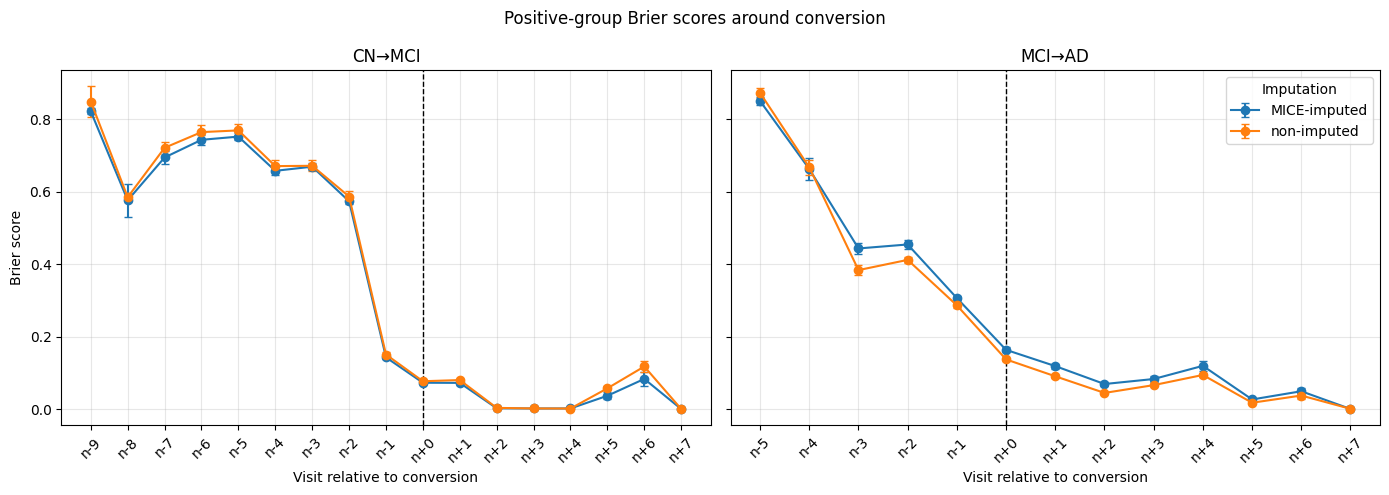

In [4]:
# Fix the plot: the summary dataframe uses cohort names like "CN_MCI" / "MCI_AD",
# but the plotting loop was filtering for "CN-MCI" / "MCI-AD".
# Normalize to a display label before plotting.

brier_positive_summary = brier_positive_summary.copy()
brier_positive_summary["cohort_plot"] = brier_positive_summary["cohort"].str.replace("_", "-", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, cohort_key in zip(axes, ["CN_MCI", "MCI_AD"]):
    display_name = cohort_key.replace("_", "→")
    cohort_summary = brier_positive_summary[
        brier_positive_summary["cohort_plot"] == cohort_key.replace("_", "-")
    ].copy()

    if cohort_summary.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(display_name)
        continue

    cohort_summary = cohort_summary.sort_values(["imputation", "offset"])

    for imp, group in cohort_summary.groupby("imputation"):
        group = group.sort_values("offset")
        if group.empty:
            continue

        ax.errorbar(
            group["offset"],
            group["brier_mean"],
            yerr=[
                group["brier_mean"] - group["brier_ci_lower"],
                group["brier_ci_upper"] - group["brier_mean"],
            ],
            marker="o",
            capsize=3,
            label=str(imp),
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(display_name)
    ax.set_xlabel("Visit relative to conversion")
    ax.set_xticks(sorted(cohort_summary["offset"].unique()))
    ax.set_xticklabels(
        [f"n{offset:+d}" for offset in sorted(cohort_summary["offset"].unique())],
        rotation=45,
    )
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Brier score")
axes[1].legend(title="Imputation")
fig.suptitle("Positive-group Brier scores around conversion")
fig.tight_layout()
plt.show()